In [1]:
% setup environment
% clear data and number format
clear; format short e
% set path to equilibrium solver
txt=pwd; n=length(txt); rootpath=txt;
n=strfind(rootpath,"USERS"); rootpath=txt(1:n-2);
PHREEQCpath=[rootpath,'/runPHREEQC']
addpath(PHREEQCpath);
JEQUILIBpath=[rootpath,'/JEQUILIB'];
addpath(JEQUILIBpath);
% turn off warnings
warning off
%graphics_toolkit ("notebook"); 
%graphics_toolkit ("plotly"); 
graphics_toolkit("gnuplot")
% delete phreeqcrunfile
%system("rm porttest.txt");
%system('export PATH="$PATH:PHREEQCpath"')
%system('phreeqc')


PHREEQCpath = /home/jupyter/DrSmith/GeochemEquilib/runPHREEQC


In [2]:
database=['llnl.dat'];

In [3]:
% variables

% amounts
XP=0.020; XPstr=num2str(XP);
XC=1e-6; XCstr=num2str(XC);
XW=0.0011; XWstr=num2str(XW);
logPCO2=-3.3;   % PCO2. measured at 468.4 ppm average in the room 
logPCO2str=num2str(logPCO2);

% Ksp values
KspP=0.00000660693; KspPstr=num2str(KspP); % from https://www.aqion.de/site/16 0.00000660693
KspC=10^-8.48; KspCstr=num2str(KspC); % for calcite from aquaion 
KspW=10^3.4; KspWstr=num2str(KspW); %google AI reported the value. combine with SiO3+H=HSiO3 Ka value

% rate constants

kP=9e-1; kPstr=num2str(kP); %port dissoltuion
kC=0.04e-2;  kCstr=num2str(kC); %calciate ppte
kCO2=0.63e-3; kCO2str=num2str(kCO2); % gas transfer
kW=3e-1; kWstr=num2str(kW); %wollastonite solubility rate

% time vector
logtime=0.05:0.05:2.2; time=[10.^logtime];
%timetry=[0.00 0.10 2.00 24.00 48.00 72.00 96.00 144.00]; time=timetry;

In [4]:
solutionboxtext=[...
{'SOLUTION 1\n'}
{'       pe      13.75\n'}
{'       pH      5.65\n'}
{'       temp    25\n'}
{'-units mol/kgw\n'}
   ];
[nolinesSOLN,length]=size(solutionboxtext);

In [5]:
rateboxtext=[...
{'RATES\n'}

{'Portlandite\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. PARM(2) Ksp for portlandite \n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 OH=Act("OH-")\n'}
{'4 IAP=Ca*OH^2\n'}
{'5 Ksp=PARM(2)\n'}
{'6 si_pp=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_pp < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_pp))^0.48)\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'Calcite\n'}
{'-start\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. Parm(2)=Ksp calcite\n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 CO3=Act("CO3-2")\n'}
{'4 IAP=Ca*CO3\n'}
{'5 Ksp=PARM(2)\n'}
{'6 si_cc=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_cc < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_cc))^0.48)\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'Wollastonite\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. Parm(2)=Ksp Wollastonite\n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 HSiO3=Act("HSiO3-")\n'}
{'4 H=Act("H+")\n'}
{'5 IAP=(Ca*HSiO3)/H \n'}
{'6 Ksp=PARM(2)\n'}
{'7 si_ww=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_cc < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_ww)))\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'CO2_dissolution\n'}
{'-start\n'}
{'20 k = parm(2)\n'}
{'30 eq_HCO3 = 10^PARM(1)*10^LK_PHASE("CO2(g)")/ACT("H+")\n'}
{'40 act_HCO3 = ACT("HCO3-")\n'}
{'50 moles = k * (1-(act_HCO3/eq_HCO3)^0.2) * TIME\n'}
{'60 SAVE moles\n'}
{'   -end\n'}
];
[nolinesRATE,length]=size(rateboxtext);

In [6]:
m0Pline=['  -m0    ',XPstr,'\n'];
mPline=['  -m    ',XPstr,'\n'];
parmsPline=['  -parms ',kPstr,' ',KspPstr,'\n'];

m0Cline=['  -m0    ',XCstr,'\n'];
mCline=['  -m    ',XCstr,'\n'];
parmsCline=['  -parms ',kCstr,' ',KspCstr,'\n'];

m0Wline=['  -m0    ',XWstr,'\n'];
mWline=['  -m    ',XWstr,'\n'];
parmsWline=['  -parms ',kWstr,' ',KspWstr,'\n'];

parmsCO2line=['  -parms ',logPCO2str,' ',kCO2str,'\n'];
timestr=mat2str([0 time]); timestr = regexprep(timestr,'\[','');  timestr = regexprep(timestr,'\]','');
timeline=[' -steps ',timestr,' s\n'];

kineticsboxtext=[...
{'KINETICS 1\n'}

{'Portlandite\n'}
{'  -tol   1e-13\n'}
{m0Pline}
{mPline}
{parmsPline}

{'Calcite\n'}
{'  -tol   1e-13\n'}
{m0Cline}
{mCline}
{parmsCline}

{'Wollastonite\n'}
{'  -tol   1e-13\n'}
{m0Wline}
{mWline}
{parmsWline}

{'CO2_dissolution\n'}
{'  -tol   1e-13\n'}
{'-formula CO2 1\n'}
{parmsCO2line}
{timeline}

{'  -cvode\n'}
{'-runge_kutta      6\n'}
];

[nolinesKIN,length]=size(kineticsboxtext);

In [7]:
selectboxtext=[...
{' SELECTED_OUTPUT\n'}
{' -file portout.txt\n'}
{' -selected_out true\n'}
{' -user_punch true\n'}
{' -high_precision true\n'}
{' -reset false\n'}
{' -simulation false\n'}
{' -state false\n'}
{' -distance false\n'}
{' -time false\n'}
{' -step false\n'}
{' -ph false\n'}
{' -pe false\n'}
{' -reaction false\n'}
{' -temperature false\n'}
{' -alkalinity false\n'}
{' -ionic_strength false\n'}
{' -water false\n'}
{' -charge_balance false\n'}
{' -percent_error false\n'}
];
[nolinesSEL,length]=size(selectboxtext);

In [8]:
punchboxtext=[...
{'USER_PUNCH\n'}
{'        -headings seconds  Ca  pH Calcite  Portlandite DIC Si\n'}
{'  10 PUNCH SIM_TIME, TOT("Ca"), -LA("H+"), KIN("Calcite"), KIN("Portlandite"), TOT("C"), TOT("Si") \n'}
];
[nolinesPUNCH,length]=size(punchboxtext);

In [9]:
fileID=fopen('porttest.txt','w');

fprintf(fileID,'TITLE TEST PORTLANDITE DISSOLUTION\n');

for i=1:nolinesSOLN
    line=cell2mat(solutionboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesRATE
    line=cell2mat(rateboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesKIN
    line=cell2mat(kineticsboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesSEL
    line=cell2mat(selectboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesPUNCH
    line=cell2mat(punchboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
fprintf(fileID,'END');
fclose(fileID);

In [10]:
str=['system("/home/jupyter/DrSmith/GeochemEquilib/runPHREEQC/phreeqc porttest.txt out.txt ', database,'");'];
eval(str); % output to the screen
%evalc(str); % so no screen output
fid = fopen('portout.txt','rt');
hdr = strtrim(regexp(fgetl(fid),'\t','split'));
hdr=hdr(1:7)';
mat = cell2mat(textscan(fid,repmat('%f',1,numel(hdr))));
[nsize,msize]=size(mat);
time=mat(2:nsize,1); Caphreeqc=mat(2:nsize,2); pHphreeqc=mat(2:nsize,3);
calcitephreeqc=mat(2:nsize,4); portlanditephreeqc=mat(2:nsize,5);
DIC=mat(2:nsize,6); Siaq=mat(2:nsize,7);

Input file: porttest.txt

Output file: out.txt

Database file: llnl.dat


Initializing...                                                                 







Simulation 1. Kinetic step 2.                                                  











Simulation 1. Kinetic step 3.                                                  







Simulation 1. Kinetic step 4.                                                  









Simulation 1. Kinetic step 5.                                                  











Simulation 1. Kinetic step 6.                                                  









Simulation 1. Kinetic step 7.                                                  







Simulation 1. Kinetic step 8.                                                  











Simulation 1. Kinetic step 8.                                                  









Simulation 1. Kinetic step 9.                                                  









Simulation 1. Kinetic step 10.     

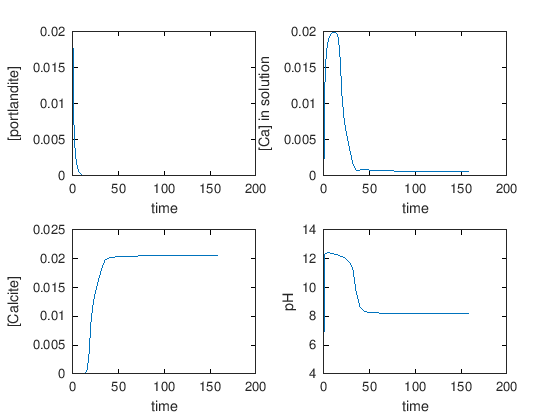

In [11]:

subplot(221); plot(time,portlanditephreeqc); ylabel('[portlandite]'); xlabel('time')
subplot(222); plot(time,Caphreeqc); ylabel('[Ca] in solution'); xlabel('time')
subplot(223); plot(time,calcitephreeqc); ylabel('[Calcite]'); xlabel('time')
subplot(224); plot(time,pHphreeqc); ylabel('pH'); xlabel('time')



In [12]:
% data
%6 g cement small size

data=[...
%Sampling times (H)	pH A	DIC A (mmol/L)	Conductivity A (us/cm)	Ca2+ (mmol/L)	Si (mmol/L)
0.00	6.79	-0.5326	NaN	0.3009
0.10	12.67	-0.0239	57	9.6393
2.00	12.41	-0.1910	7430	23.7760
24.00	12.42	-0.2835	8670	19.6788
48.00	12.30	-0.2972	7980	21.4330
72.00	8.28	-0.3844	6250	16.1675
96.00	8.19	0.5037	253	0.7056
144.00	8.16	0.4681	271	0.7288

];

sampletime=data(:,1); samplepH=data(:,2); sampleDIC=(data(:,3)*1e-3); conduct=data(:,4); sampleCa=(data(:,5)*1e-3); 
sampleSi=(data(:,6)*1e-3);


error: data(_,6): out of bound 5 (dimensions are 8x5)


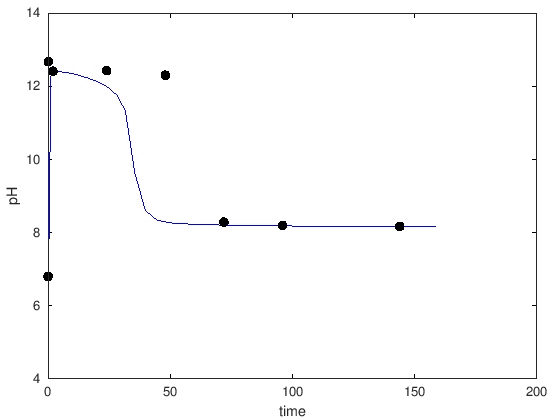

In [13]:
plot(time,pHphreeqc,'b-','linewidth',2); ylabel('pH'); xlabel('time')
hold on
%plot(timeres,pHres,'bo')
plot(sampletime,samplepH,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

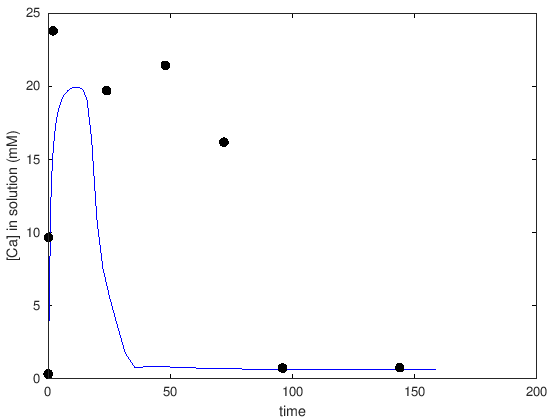

In [14]:
plot(time,(Caphreeqc*1e3),'b-','linewidth',2); ylabel('[Ca] in solution (mM)'); xlabel('time')
hold on
plot(sampletime,(sampleCa*1e3),'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

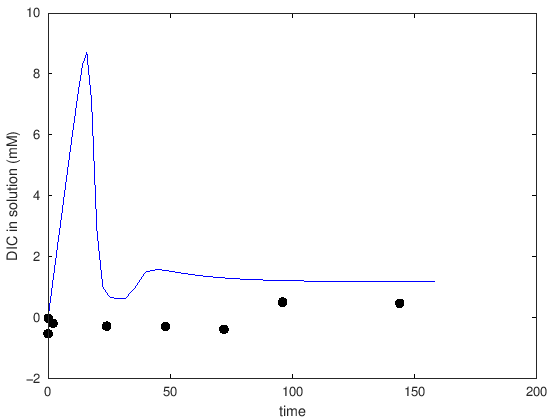

In [15]:
plot(time,1e3*DIC,'b-','linewidth',2); ylabel('DIC in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleDIC*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

error: 'sampleSi' undefined near line 1, column 17


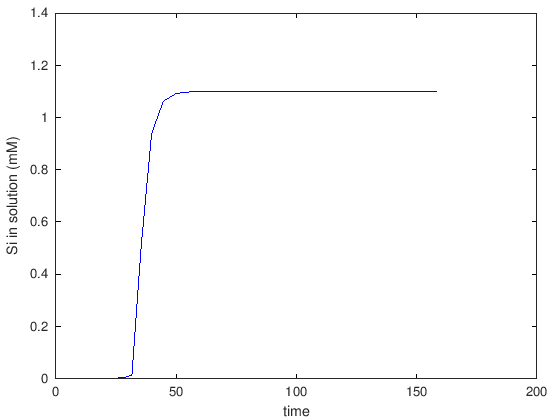

In [16]:
plot(time,1e3*(Siaq),'b-','linewidth',2); ylabel('Si in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleSi*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

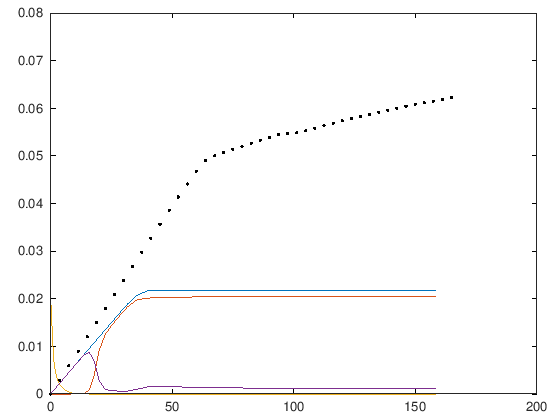

In [17]:
% plot total C that ends up in solution

CTsoln=DIC+calcitephreeqc;

%plot(time,CTsoln,time,calcite,time,port,time,DIC,sampletime,sampleDIC,'r.')
plot(time,CTsoln,time,calcitephreeqc,time,portlanditephreeqc,time,DIC,'linewidth',2)


data=[...
%Time (min)	Time(h)	Carbon dioxide(ppm)	CO2_input (mol)	CO2_out (mol)	△ CO2 consumed (mol)	CO2 capture rate （umol/5 min）	CO2 capture rate （umol/h）	CO2 capture （umol）
0	0	557	6.7304E-05	6.7304E-05	0.0000E+00	0.0000E+00	0.0000E+00	0.0000E+00
5	0.083333333	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	9.1833E+00
10	0.166666667	263	6.7304E-05	3.1779E-05	3.5525E-05	3.5525E+01	4.2630E+02	4.4708E+01
15	0.25	130	6.7304E-05	1.5708E-05	5.1596E-05	5.1596E+01	6.1915E+02	9.6304E+01
20	0.333333333	55	6.7304E-05	6.6458E-06	6.0658E-05	6.0658E+01	7.2790E+02	1.5696E+02
25	0.416666667	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	2.2209E+02
30	0.5	7	6.7304E-05	8.4583E-07	6.6458E-05	6.6458E+01	7.9750E+02	2.8855E+02
35	0.583333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.5585E+02
40	0.666666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.2316E+02
45	0.75	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.9046E+02
50	0.833333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	5.5777E+02
55	0.916666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.2507E+02
60	1	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.9238E+02
65	1.083333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	7.5968E+02
70	1.166666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	8.2698E+02
75	1.25	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	8.9429E+02
80	1.333333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	9.6159E+02
85	1.416666667	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	1.0282E+03
90	1.5	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	1.0938E+03
95	1.583333333	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	1.1601E+03
100	1.666666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.2274E+03
105	1.75	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.2947E+03
110	1.833333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.3620E+03
115	1.916666667	5	6.7304E-05	6.0417E-07	6.6700E-05	6.6700E+01	8.0040E+02	1.4287E+03
120	2	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.4960E+03
125	2.083333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.5633E+03
130	2.166666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.6306E+03
135	2.25	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.6980E+03
140	2.333333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.7653E+03
145	2.416666667	3	6.7304E-05	3.6250E-07	6.6942E-05	6.6942E+01	8.0330E+02	1.8322E+03
150	2.5	1	6.7304E-05	1.2083E-07	6.7183E-05	6.7183E+01	8.0620E+02	1.8994E+03
155	2.583333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.9667E+03
160	2.666666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	2.0340E+03
165	2.75	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	2.1013E+03
170	2.833333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	2.1686E+03
175	2.916666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	2.2359E+03
180	3	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	2.3032E+03
185	3.083333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	2.3705E+03
190	3.166666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	2.4378E+03
195	3.25	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	2.5051E+03
200	3.333333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	2.5724E+03
205	3.416666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	2.6397E+03
210	3.5	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	2.7070E+03
215	3.583333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	2.7743E+03
220	3.666666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	2.8416E+03
225	3.75	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	2.9089E+03
230	3.833333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	2.9762E+03
235	3.916666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.0436E+03
240	4	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.1109E+03
245	4.083333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.1782E+03
250	4.166666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.2455E+03
255	4.25	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.3128E+03
260	4.333333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.3801E+03
265	4.416666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.4474E+03
270	4.5	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.5147E+03
275	4.583333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.5820E+03
280	4.666666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.6493E+03
285	4.75	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.7166E+03
290	4.833333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.7839E+03
295	4.916666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.8512E+03
300	5	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.9185E+03
305	5.083333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	3.9858E+03
310	5.166666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.0531E+03
315	5.25	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.1204E+03
320	5.333333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.1877E+03
325	5.416666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.2550E+03
330	5.5	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.3223E+03
335	5.583333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.3896E+03
340	5.666666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.4569E+03
345	5.75	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.5242E+03
350	5.833333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.5915E+03
355	5.916666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.6589E+03
360	6	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.7262E+03
365	6.083333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.7935E+03
370	6.166666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.8608E+03
375	6.25	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.9281E+03
380	6.333333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	4.9954E+03
385	6.416666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	5.0627E+03
390	6.5	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	5.1300E+03
395	6.583333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	5.1973E+03
400	6.666666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	5.2646E+03
405	6.75	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	5.3319E+03
410	6.833333333	1	6.7304E-05	1.2083E-07	6.7183E-05	6.7183E+01	8.0620E+02	5.3991E+03
415	6.916666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	5.4664E+03
420	7	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	5.5337E+03
425	7.083333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	5.6010E+03
430	7.166666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	5.6683E+03
435	7.25	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	5.7356E+03
440	7.333333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	5.8029E+03
445	7.416666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	5.8702E+03
450	7.5	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	5.9375E+03
455	7.583333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.0048E+03
460	7.666666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.0721E+03
465	7.75	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.1394E+03
470	7.833333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.2067E+03
475	7.916666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.2740E+03
480	8	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.3413E+03
485	8.083333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.4086E+03
490	8.166666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.4759E+03
495	8.25	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.5432E+03
500	8.333333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.6106E+03
505	8.416666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.6779E+03
510	8.5	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.7452E+03
515	8.583333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.8125E+03
520	8.666666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.8798E+03
525	8.75	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.9471E+03
530	8.833333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	7.0144E+03
535	8.916666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	7.0817E+03
540	9	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	7.1490E+03
545	9.083333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	7.2163E+03
550	9.166666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	7.2836E+03
555	9.25	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	7.3509E+03
560	9.333333333	3	6.7304E-05	3.6250E-07	6.6942E-05	6.6942E+01	8.0330E+02	7.4178E+03
565	9.416666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	7.4851E+03
570	9.5	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	7.5524E+03
575	9.583333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	7.6198E+03
580	9.666666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	7.6871E+03
585	9.75	3	6.7304E-05	3.6250E-07	6.6942E-05	6.6942E+01	8.0330E+02	7.7540E+03
590	9.833333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	7.8213E+03
595	9.916666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	7.8886E+03
600	10	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	7.9559E+03
605	10.08333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	8.0232E+03
610	10.16666667	3	6.7304E-05	3.6250E-07	6.6942E-05	6.6942E+01	8.0330E+02	8.0902E+03
615	10.25	2	6.7304E-05	2.4167E-07	6.7063E-05	6.7063E+01	8.0475E+02	8.1572E+03
620	10.33333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	8.2245E+03
625	10.41666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	8.2918E+03
630	10.5	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	8.3584E+03
635	10.58333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	8.4257E+03
640	10.66666667	1	6.7304E-05	1.2083E-07	6.7183E-05	6.7183E+01	8.0620E+02	8.4929E+03
645	10.75	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	8.5602E+03
650	10.83333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	8.6275E+03
655	10.91666667	3	6.7304E-05	3.6250E-07	6.6942E-05	6.6942E+01	8.0330E+02	8.6944E+03
660	11	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	8.7617E+03
665	11.08333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	8.8291E+03
670	11.16666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	8.8964E+03
675	11.25	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	8.9629E+03
680	11.33333333	2	6.7304E-05	2.4167E-07	6.7063E-05	6.7063E+01	8.0475E+02	9.0300E+03
685	11.41666667	1	6.7304E-05	1.2083E-07	6.7183E-05	6.7183E+01	8.0620E+02	9.0972E+03
690	11.5	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	9.1645E+03
695	11.58333333	3	6.7304E-05	3.6250E-07	6.6942E-05	6.6942E+01	8.0330E+02	9.2314E+03
700	11.66666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	9.2987E+03
705	11.75	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	9.3660E+03
710	11.83333333	1	6.7304E-05	1.2083E-07	6.7183E-05	6.7183E+01	8.0620E+02	9.4332E+03
715	11.91666667	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	9.5000E+03
720	12	5	6.7304E-05	6.0417E-07	6.6700E-05	6.6700E+01	8.0040E+02	9.5667E+03
725	12.08333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	9.6340E+03
730	12.16666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	9.7013E+03
735	12.25	3	6.7304E-05	3.6250E-07	6.6942E-05	6.6942E+01	8.0330E+02	9.7683E+03
740	12.33333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	9.8356E+03
745	12.41666667	5	6.7304E-05	6.0417E-07	6.6700E-05	6.6700E+01	8.0040E+02	9.9023E+03
750	12.5	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	9.9696E+03
755	12.58333333	1	6.7304E-05	1.2083E-07	6.7183E-05	6.7183E+01	8.0620E+02	1.0037E+04
760	12.66666667	3	6.7304E-05	3.6250E-07	6.6942E-05	6.6942E+01	8.0330E+02	1.0104E+04
765	12.75	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.0171E+04
770	12.83333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.0238E+04
775	12.91666667	2	6.7304E-05	2.4167E-07	6.7063E-05	6.7063E+01	8.0475E+02	1.0305E+04
780	13	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	1.0372E+04
785	13.08333333	5	6.7304E-05	6.0417E-07	6.6700E-05	6.6700E+01	8.0040E+02	1.0439E+04
790	13.16666667	3	6.7304E-05	3.6250E-07	6.6942E-05	6.6942E+01	8.0330E+02	1.0506E+04
795	13.25	2	6.7304E-05	2.4167E-07	6.7063E-05	6.7063E+01	8.0475E+02	1.0573E+04
800	13.33333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.0640E+04
805	13.41666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.0708E+04
810	13.5	7	6.7304E-05	8.4583E-07	6.6458E-05	6.6458E+01	7.9750E+02	1.0774E+04
815	13.58333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.0841E+04
820	13.66666667	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	1.0908E+04
825	13.75	7	6.7304E-05	8.4583E-07	6.6458E-05	6.6458E+01	7.9750E+02	1.0974E+04
830	13.83333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.1042E+04
835	13.91666667	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	1.1108E+04
840	14	2	6.7304E-05	2.4167E-07	6.7063E-05	6.7063E+01	8.0475E+02	1.1175E+04
845	14.08333333	1	6.7304E-05	1.2083E-07	6.7183E-05	6.7183E+01	8.0620E+02	1.1242E+04
850	14.16666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.1309E+04
855	14.25	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.1377E+04
860	14.33333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.1444E+04
865	14.41666667	7	6.7304E-05	8.4583E-07	6.6458E-05	6.6458E+01	7.9750E+02	1.1510E+04
870	14.5	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.1578E+04
875	14.58333333	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	1.1644E+04
880	14.66666667	2	6.7304E-05	2.4167E-07	6.7063E-05	6.7063E+01	8.0475E+02	1.1711E+04
885	14.75	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.1779E+04
890	14.83333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.1846E+04
895	14.91666667	2	6.7304E-05	2.4167E-07	6.7063E-05	6.7063E+01	8.0475E+02	1.1913E+04
900	15	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	1.1979E+04
905	15.08333333	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	1.2046E+04
910	15.16666667	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	1.2113E+04
915	15.25	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.2180E+04
920	15.33333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.2247E+04
925	15.41666667	3	6.7304E-05	3.6250E-07	6.6942E-05	6.6942E+01	8.0330E+02	1.2314E+04
930	15.5	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	1.2381E+04
935	15.58333333	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	1.2448E+04
940	15.66666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.2515E+04
945	15.75	3	6.7304E-05	3.6250E-07	6.6942E-05	6.6942E+01	8.0330E+02	1.2582E+04
950	15.83333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.2649E+04
955	15.91666667	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	1.2716E+04
960	16	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	1.2782E+04
965	16.08333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.2850E+04
970	16.16666667	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	1.2916E+04
975	16.25	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.2983E+04
980	16.33333333	3	6.7304E-05	3.6250E-07	6.6942E-05	6.6942E+01	8.0330E+02	1.3050E+04
985	16.41666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.3118E+04
990	16.5	1	6.7304E-05	1.2083E-07	6.7183E-05	6.7183E+01	8.0620E+02	1.3185E+04
995	16.58333333	5	6.7304E-05	6.0417E-07	6.6700E-05	6.6700E+01	8.0040E+02	1.3252E+04
1000	16.66666667	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	1.3318E+04
1005	16.75	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.3385E+04
1010	16.83333333	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	1.3452E+04
1015	16.91666667	7	6.7304E-05	8.4583E-07	6.6458E-05	6.6458E+01	7.9750E+02	1.3519E+04
1020	17	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.3586E+04
1025	17.08333333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.3653E+04
1030	17.16666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.3721E+04
1035	17.25	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.3788E+04
1040	17.33333333	2	6.7304E-05	2.4167E-07	6.7063E-05	6.7063E+01	8.0475E+02	1.3855E+04
1045	17.41666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.3922E+04
1050	17.5	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	1.3988E+04
1055	17.58333333	1	6.7304E-05	1.2083E-07	6.7183E-05	6.7183E+01	8.0620E+02	1.4055E+04
1060	17.66666667	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	1.4121E+04
1065	17.75	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	1.4188E+04
1070	17.83333333	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	1.4255E+04
1075	17.91666667	5	6.7304E-05	6.0417E-07	6.6700E-05	6.6700E+01	8.0040E+02	1.4321E+04
1080	18	11	6.7304E-05	1.3292E-06	6.5975E-05	6.5975E+01	7.9170E+02	1.4387E+04
1085	18.08333333	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	1.4454E+04
1090	18.16666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.4521E+04
1095	18.25	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	1.4587E+04
1100	18.33333333	3	6.7304E-05	3.6250E-07	6.6942E-05	6.6942E+01	8.0330E+02	1.4654E+04
1105	18.41666667	5	6.7304E-05	6.0417E-07	6.6700E-05	6.6700E+01	8.0040E+02	1.4721E+04
1110	18.5	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	1.4788E+04
1115	18.58333333	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	1.4854E+04
1120	18.66666667	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	1.4920E+04
1125	18.75	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	1.4986E+04
1130	18.83333333	2	6.7304E-05	2.4167E-07	6.7063E-05	6.7063E+01	8.0475E+02	1.5053E+04
1135	18.91666667	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	1.5119E+04
1140	19	7	6.7304E-05	8.4583E-07	6.6458E-05	6.6458E+01	7.9750E+02	1.5185E+04
1145	19.08333333	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	1.5252E+04
1150	19.16666667	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	1.5318E+04
1155	19.25	3	6.7304E-05	3.6250E-07	6.6942E-05	6.6942E+01	8.0330E+02	1.5385E+04
1160	19.33333333	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	1.5451E+04
1165	19.41666667	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	1.5517E+04
1170	19.5	2	6.7304E-05	2.4167E-07	6.7063E-05	6.7063E+01	8.0475E+02	1.5584E+04
1175	19.58333333	5	6.7304E-05	6.0417E-07	6.6700E-05	6.6700E+01	8.0040E+02	1.5651E+04
1180	19.66666667	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	1.5717E+04
1185	19.75	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	1.5784E+04
1190	19.83333333	5	6.7304E-05	6.0417E-07	6.6700E-05	6.6700E+01	8.0040E+02	1.5850E+04
1195	19.91666667	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	1.5917E+04
1200	20	2	6.7304E-05	2.4167E-07	6.7063E-05	6.7063E+01	8.0475E+02	1.5984E+04
1205	20.08333333	11	6.7304E-05	1.3292E-06	6.5975E-05	6.5975E+01	7.9170E+02	1.6050E+04
1210	20.16666667	7	6.7304E-05	8.4583E-07	6.6458E-05	6.6458E+01	7.9750E+02	1.6116E+04
1215	20.25	2	6.7304E-05	2.4167E-07	6.7063E-05	6.7063E+01	8.0475E+02	1.6183E+04
1220	20.33333333	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	1.6249E+04
1225	20.41666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	1.6316E+04
1230	20.5	11	6.7304E-05	1.3292E-06	6.5975E-05	6.5975E+01	7.9170E+02	1.6382E+04
1235	20.58333333	7	6.7304E-05	8.4583E-07	6.6458E-05	6.6458E+01	7.9750E+02	1.6449E+04
1240	20.66666667	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	1.6515E+04
1245	20.75	11	6.7304E-05	1.3292E-06	6.5975E-05	6.5975E+01	7.9170E+02	1.6581E+04
1250	20.83333333	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	1.6647E+04
1255	20.91666667	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	1.6713E+04
1260	21	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	1.6779E+04
1265	21.08333333	2	6.7304E-05	2.4167E-07	6.7063E-05	6.7063E+01	8.0475E+02	1.6846E+04
1270	21.16666667	7	6.7304E-05	8.4583E-07	6.6458E-05	6.6458E+01	7.9750E+02	1.6912E+04
1275	21.25	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	1.6979E+04
1280	21.33333333	11	6.7304E-05	1.3292E-06	6.5975E-05	6.5975E+01	7.9170E+02	1.7045E+04
1285	21.41666667	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	1.7111E+04
1290	21.5	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	1.7178E+04
1295	21.58333333	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	1.7243E+04
1300	21.66666667	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	1.7309E+04
1305	21.75	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	1.7376E+04
1310	21.83333333	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	1.7443E+04
1315	21.91666667	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	1.7509E+04
1320	22	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	1.7576E+04
1325	22.08333333	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	1.7643E+04
1330	22.16666667	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	1.7709E+04
1335	22.25	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	1.7775E+04
1340	22.33333333	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	1.7842E+04
1345	22.41666667	1	6.7304E-05	1.2083E-07	6.7183E-05	6.7183E+01	8.0620E+02	1.7909E+04
1350	22.5	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	1.7974E+04
1355	22.58333333	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	1.8039E+04
1360	22.66666667	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	1.8104E+04
1365	22.75	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	1.8170E+04
1370	22.83333333	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	1.8236E+04
1375	22.91666667	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	1.8302E+04
1380	23	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	1.8368E+04
1385	23.08333333	11	6.7304E-05	1.3292E-06	6.5975E-05	6.5975E+01	7.9170E+02	1.8434E+04
1390	23.16666667	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	1.8499E+04
1395	23.25	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	1.8565E+04
1400	23.33333333	11	6.7304E-05	1.3292E-06	6.5975E-05	6.5975E+01	7.9170E+02	1.8631E+04
1405	23.41666667	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	1.8696E+04
1410	23.5	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	1.8762E+04
1415	23.58333333	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	1.8829E+04
1420	23.66666667	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	1.8894E+04
1425	23.75	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	1.8959E+04
1430	23.83333333	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	1.9024E+04
1435	23.91666667	7	6.7304E-05	8.4583E-07	6.6458E-05	6.6458E+01	7.9750E+02	1.9090E+04
1440	24	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	1.9156E+04
1445	24.08333333	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	1.9222E+04
1450	24.16666667	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	1.9288E+04
1455	24.25	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	1.9354E+04
1460	24.33333333	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	1.9420E+04
1465	24.41666667	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	1.9487E+04
1470	24.5	1	6.7304E-05	1.2083E-07	6.7183E-05	6.7183E+01	8.0620E+02	1.9554E+04
1475	24.58333333	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	1.9619E+04
1480	24.66666667	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	1.9685E+04
1485	24.75	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	1.9750E+04
1490	24.83333333	2	6.7304E-05	2.4167E-07	6.7063E-05	6.7063E+01	8.0475E+02	1.9817E+04
1495	24.91666667	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	1.9883E+04
1500	25	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	1.9949E+04
1505	25.08333333	2	6.7304E-05	2.4167E-07	6.7063E-05	6.7063E+01	8.0475E+02	2.0016E+04
1510	25.16666667	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	2.0081E+04
1515	25.25	5	6.7304E-05	6.0417E-07	6.6700E-05	6.6700E+01	8.0040E+02	2.0148E+04
1520	25.33333333	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	2.0214E+04
1525	25.41666667	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	2.0280E+04
1530	25.5	23	6.7304E-05	2.7792E-06	6.4525E-05	6.4525E+01	7.7430E+02	2.0344E+04
1535	25.58333333	11	6.7304E-05	1.3292E-06	6.5975E-05	6.5975E+01	7.9170E+02	2.0410E+04
1540	25.66666667	21	6.7304E-05	2.5375E-06	6.4767E-05	6.4767E+01	7.7720E+02	2.0475E+04
1545	25.75	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	2.0541E+04
1550	25.83333333	11	6.7304E-05	1.3292E-06	6.5975E-05	6.5975E+01	7.9170E+02	2.0607E+04
1555	25.91666667	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	2.0672E+04
1560	26	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	2.0737E+04
1565	26.08333333	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	2.0802E+04
1570	26.16666667	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	2.0868E+04
1575	26.25	11	6.7304E-05	1.3292E-06	6.5975E-05	6.5975E+01	7.9170E+02	2.0934E+04
1580	26.33333333	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	2.0999E+04
1585	26.41666667	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	2.1065E+04
1590	26.5	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	2.1130E+04
1595	26.58333333	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	2.1197E+04
1600	26.66666667	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	2.1262E+04
1605	26.75	11	6.7304E-05	1.3292E-06	6.5975E-05	6.5975E+01	7.9170E+02	2.1328E+04
1610	26.83333333	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	2.1394E+04
1615	26.91666667	11	6.7304E-05	1.3292E-06	6.5975E-05	6.5975E+01	7.9170E+02	2.1460E+04
1620	27	7	6.7304E-05	8.4583E-07	6.6458E-05	6.6458E+01	7.9750E+02	2.1527E+04
1625	27.08333333	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	2.1592E+04
1630	27.16666667	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	2.1657E+04
1635	27.25	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	2.1722E+04
1640	27.33333333	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	2.1788E+04
1645	27.41666667	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	2.1853E+04
1650	27.5	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	2.1919E+04
1655	27.58333333	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	2.1984E+04
1660	27.66666667	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	2.2050E+04
1665	27.75	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	2.2116E+04
1670	27.83333333	24	6.7304E-05	2.9000E-06	6.4404E-05	6.4404E+01	7.7285E+02	2.2180E+04
1675	27.91666667	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	2.2246E+04
1680	28	26	6.7304E-05	3.1417E-06	6.4163E-05	6.4163E+01	7.6995E+02	2.2310E+04
1685	28.08333333	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	2.2375E+04
1690	28.16666667	3	6.7304E-05	3.6250E-07	6.6942E-05	6.6942E+01	8.0330E+02	2.2442E+04
1695	28.25	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	2.2508E+04
1700	28.33333333	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	2.2574E+04
1705	28.41666667	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	2.2641E+04
1710	28.5	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	2.2707E+04
1715	28.58333333	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	2.2773E+04
1720	28.66666667	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	2.2838E+04
1725	28.75	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	2.2903E+04
1730	28.83333333	7	6.7304E-05	8.4583E-07	6.6458E-05	6.6458E+01	7.9750E+02	2.2970E+04
1735	28.91666667	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	2.3035E+04
1740	29	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	2.3101E+04
1745	29.08333333	28	6.7304E-05	3.3833E-06	6.3921E-05	6.3921E+01	7.6705E+02	2.3165E+04
1750	29.16666667	21	6.7304E-05	2.5375E-06	6.4767E-05	6.4767E+01	7.7720E+02	2.3230E+04
1755	29.25	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	2.3296E+04
1760	29.33333333	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	2.3361E+04
1765	29.41666667	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	2.3427E+04
1770	29.5	22	6.7304E-05	2.6583E-06	6.4646E-05	6.4646E+01	7.7575E+02	2.3492E+04
1775	29.58333333	21	6.7304E-05	2.5375E-06	6.4767E-05	6.4767E+01	7.7720E+02	2.3557E+04
1780	29.66666667	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	2.3622E+04
1785	29.75	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	2.3687E+04
1790	29.83333333	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	2.3752E+04
1795	29.91666667	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	2.3818E+04
1800	30	21	6.7304E-05	2.5375E-06	6.4767E-05	6.4767E+01	7.7720E+02	2.3882E+04
1805	30.08333333	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	2.3949E+04
1810	30.16666667	22	6.7304E-05	2.6583E-06	6.4646E-05	6.4646E+01	7.7575E+02	2.4013E+04
1815	30.25	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	2.4078E+04
1820	30.33333333	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	2.4143E+04
1825	30.41666667	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	2.4208E+04
1830	30.5	22	6.7304E-05	2.6583E-06	6.4646E-05	6.4646E+01	7.7575E+02	2.4273E+04
1835	30.58333333	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	2.4338E+04
1840	30.66666667	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	2.4404E+04
1845	30.75	25	6.7304E-05	3.0208E-06	6.4283E-05	6.4283E+01	7.7140E+02	2.4468E+04
1850	30.83333333	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	2.4534E+04
1855	30.91666667	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	2.4600E+04
1860	31	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	2.4666E+04
1865	31.08333333	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	2.4732E+04
1870	31.16666667	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	2.4798E+04
1875	31.25	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	2.4863E+04
1880	31.33333333	21	6.7304E-05	2.5375E-06	6.4767E-05	6.4767E+01	7.7720E+02	2.4928E+04
1885	31.41666667	7	6.7304E-05	8.4583E-07	6.6458E-05	6.6458E+01	7.9750E+02	2.4994E+04
1890	31.5	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	2.5060E+04
1895	31.58333333	26	6.7304E-05	3.1417E-06	6.4163E-05	6.4163E+01	7.6995E+02	2.5124E+04
1900	31.66666667	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	2.5190E+04
1905	31.75	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	2.5255E+04
1910	31.83333333	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	2.5321E+04
1915	31.91666667	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	2.5386E+04
1920	32	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	2.5452E+04
1925	32.08333333	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	2.5517E+04
1930	32.16666667	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	2.5583E+04
1935	32.25	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	2.5648E+04
1940	32.33333333	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	2.5713E+04
1945	32.41666667	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	2.5779E+04
1950	32.5	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	2.5844E+04
1955	32.58333333	21	6.7304E-05	2.5375E-06	6.4767E-05	6.4767E+01	7.7720E+02	2.5908E+04
1960	32.66666667	5	6.7304E-05	6.0417E-07	6.6700E-05	6.6700E+01	8.0040E+02	2.5975E+04
1965	32.75	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	2.6040E+04
1970	32.83333333	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	2.6105E+04
1975	32.91666667	24	6.7304E-05	2.9000E-06	6.4404E-05	6.4404E+01	7.7285E+02	2.6170E+04
1980	33	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	2.6236E+04
1985	33.08333333	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	2.6302E+04
1990	33.16666667	25	6.7304E-05	3.0208E-06	6.4283E-05	6.4283E+01	7.7140E+02	2.6366E+04
1995	33.25	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	2.6433E+04
2000	33.33333333	24	6.7304E-05	2.9000E-06	6.4404E-05	6.4404E+01	7.7285E+02	2.6497E+04
2005	33.41666667	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	2.6562E+04
2010	33.5	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	2.6627E+04
2015	33.58333333	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	2.6693E+04
2020	33.66666667	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	2.6760E+04
2025	33.75	26	6.7304E-05	3.1417E-06	6.4163E-05	6.4163E+01	7.6995E+02	2.6824E+04
2030	33.83333333	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	2.6889E+04
2035	33.91666667	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	2.6954E+04
2040	34	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	2.7020E+04
2045	34.08333333	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	2.7086E+04
2050	34.16666667	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	2.7151E+04
2055	34.25	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	2.7216E+04
2060	34.33333333	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	2.7282E+04
2065	34.41666667	24	6.7304E-05	2.9000E-06	6.4404E-05	6.4404E+01	7.7285E+02	2.7346E+04
2070	34.5	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	2.7411E+04
2075	34.58333333	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	2.7477E+04
2080	34.66666667	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	2.7542E+04
2085	34.75	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	2.7607E+04
2090	34.83333333	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	2.7673E+04
2095	34.91666667	7	6.7304E-05	8.4583E-07	6.6458E-05	6.6458E+01	7.9750E+02	2.7740E+04
2100	35	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	2.7806E+04
2105	35.08333333	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	2.7871E+04
2110	35.16666667	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	2.7936E+04
2115	35.25	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	2.8002E+04
2120	35.33333333	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	2.8068E+04
2125	35.41666667	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	2.8134E+04
2130	35.5	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	2.8199E+04
2135	35.58333333	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	2.8265E+04
2140	35.66666667	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	2.8330E+04
2145	35.75	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	2.8396E+04
2150	35.83333333	21	6.7304E-05	2.5375E-06	6.4767E-05	6.4767E+01	7.7720E+02	2.8461E+04
2155	35.91666667	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	2.8526E+04
2160	36	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	2.8592E+04
2165	36.08333333	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	2.8657E+04
2170	36.16666667	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	2.8723E+04
2175	36.25	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	2.8788E+04
2180	36.33333333	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	2.8854E+04
2185	36.41666667	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	2.8919E+04
2190	36.5	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	2.8985E+04
2195	36.58333333	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	2.9051E+04
2200	36.66666667	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	2.9116E+04
2205	36.75	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	2.9181E+04
2210	36.83333333	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	2.9247E+04
2215	36.91666667	7	6.7304E-05	8.4583E-07	6.6458E-05	6.6458E+01	7.9750E+02	2.9313E+04
2220	37	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	2.9378E+04
2225	37.08333333	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	2.9444E+04
2230	37.16666667	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	2.9510E+04
2235	37.25	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	2.9575E+04
2240	37.33333333	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	2.9641E+04
2245	37.41666667	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	2.9707E+04
2250	37.5	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	2.9773E+04
2255	37.58333333	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	2.9839E+04
2260	37.66666667	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	2.9904E+04
2265	37.75	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	2.9970E+04
2270	37.83333333	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	3.0035E+04
2275	37.91666667	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	3.0101E+04
2280	38	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	3.0166E+04
2285	38.08333333	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	3.0231E+04
2290	38.16666667	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	3.0296E+04
2295	38.25	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	3.0362E+04
2300	38.33333333	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	3.0429E+04
2305	38.41666667	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	3.0495E+04
2310	38.5	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	3.0561E+04
2315	38.58333333	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	3.0627E+04
2320	38.66666667	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	3.0692E+04
2325	38.75	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	3.0757E+04
2330	38.83333333	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	3.0823E+04
2335	38.91666667	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	3.0889E+04
2340	39	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	3.0954E+04
2345	39.08333333	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	3.1020E+04
2350	39.16666667	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	3.1086E+04
2355	39.25	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	3.1153E+04
2360	39.33333333	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	3.1218E+04
2365	39.41666667	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	3.1285E+04
2370	39.5	25	6.7304E-05	3.0208E-06	6.4283E-05	6.4283E+01	7.7140E+02	3.1349E+04
2375	39.58333333	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	3.1414E+04
2380	39.66666667	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	3.1479E+04
2385	39.75	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	3.1545E+04
2390	39.83333333	5	6.7304E-05	6.0417E-07	6.6700E-05	6.6700E+01	8.0040E+02	3.1612E+04
2395	39.91666667	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	3.1677E+04
2400	40	22	6.7304E-05	2.6583E-06	6.4646E-05	6.4646E+01	7.7575E+02	3.1742E+04
2405	40.08333333	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	3.1808E+04
2410	40.16666667	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	3.1875E+04
2415	40.25	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	3.1940E+04
2420	40.33333333	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	3.2005E+04
2425	40.41666667	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	3.2071E+04
2430	40.5	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	3.2136E+04
2435	40.58333333	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	3.2202E+04
2440	40.66666667	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	3.2268E+04
2445	40.75	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	3.2334E+04
2450	40.83333333	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	3.2399E+04
2455	40.91666667	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	3.2465E+04
2460	41	10	6.7304E-05	1.2083E-06	6.6096E-05	6.6096E+01	7.9315E+02	3.2531E+04
2465	41.08333333	22	6.7304E-05	2.6583E-06	6.4646E-05	6.4646E+01	7.7575E+02	3.2596E+04
2470	41.16666667	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	3.2661E+04
2475	41.25	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	3.2726E+04
2480	41.33333333	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	3.2791E+04
2485	41.41666667	24	6.7304E-05	2.9000E-06	6.4404E-05	6.4404E+01	7.7285E+02	3.2856E+04
2490	41.5	21	6.7304E-05	2.5375E-06	6.4767E-05	6.4767E+01	7.7720E+02	3.2920E+04
2495	41.58333333	24	6.7304E-05	2.9000E-06	6.4404E-05	6.4404E+01	7.7285E+02	3.2985E+04
2500	41.66666667	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	3.3050E+04
2505	41.75	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	3.3115E+04
2510	41.83333333	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	3.3181E+04
2515	41.91666667	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	3.3247E+04
2520	42	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	3.3312E+04
2525	42.08333333	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	3.3377E+04
2530	42.16666667	22	6.7304E-05	2.6583E-06	6.4646E-05	6.4646E+01	7.7575E+02	3.3441E+04
2535	42.25	12	6.7304E-05	1.4500E-06	6.5854E-05	6.5854E+01	7.9025E+02	3.3507E+04
2540	42.33333333	14	6.7304E-05	1.6917E-06	6.5613E-05	6.5613E+01	7.8735E+02	3.3573E+04
2545	42.41666667	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	3.3638E+04
2550	42.5	6	6.7304E-05	7.2500E-07	6.6579E-05	6.6579E+01	7.9895E+02	3.3705E+04
2555	42.58333333	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	3.3771E+04
2560	42.66666667	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	3.3837E+04
2565	42.75	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	3.3902E+04
2570	42.83333333	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	3.3968E+04
2575	42.91666667	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	3.4034E+04
2580	43	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	3.4100E+04
2585	43.08333333	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	3.4165E+04
2590	43.16666667	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	3.4230E+04
2595	43.25	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	3.4295E+04
2600	43.33333333	8	6.7304E-05	9.6667E-07	6.6338E-05	6.6338E+01	7.9605E+02	3.4361E+04
2605	43.41666667	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	3.4427E+04
2610	43.5	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	3.4492E+04
2615	43.58333333	11	6.7304E-05	1.3292E-06	6.5975E-05	6.5975E+01	7.9170E+02	3.4558E+04
2620	43.66666667	4	6.7304E-05	4.8333E-07	6.6821E-05	6.6821E+01	8.0185E+02	3.4625E+04
2625	43.75	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	3.4691E+04
2630	43.83333333	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	3.4757E+04
2635	43.91666667	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	3.4822E+04
2640	44	9	6.7304E-05	1.0875E-06	6.6217E-05	6.6217E+01	7.9460E+02	3.4888E+04
2645	44.08333333	11	6.7304E-05	1.3292E-06	6.5975E-05	6.5975E+01	7.9170E+02	3.4954E+04
2650	44.16666667	21	6.7304E-05	2.5375E-06	6.4767E-05	6.4767E+01	7.7720E+02	3.5019E+04
2655	44.25	20	6.7304E-05	2.4167E-06	6.4888E-05	6.4888E+01	7.7865E+02	3.5084E+04
2660	44.33333333	21	6.7304E-05	2.5375E-06	6.4767E-05	6.4767E+01	7.7720E+02	3.5149E+04
2665	44.41666667	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	3.5215E+04
2670	44.5	13	6.7304E-05	1.5708E-06	6.5733E-05	6.5733E+01	7.8880E+02	3.5280E+04
2675	44.58333333	25	6.7304E-05	3.0208E-06	6.4283E-05	6.4283E+01	7.7140E+02	3.5345E+04
2680	44.66666667	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	3.5410E+04
2685	44.75	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	3.5475E+04
2690	44.83333333	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	3.5541E+04
2695	44.91666667	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	3.5606E+04
2700	45	22	6.7304E-05	2.6583E-06	6.4646E-05	6.4646E+01	7.7575E+02	3.5671E+04
2705	45.08333333	16	6.7304E-05	1.9333E-06	6.5371E-05	6.5371E+01	7.8445E+02	3.5736E+04
2710	45.16666667	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	3.5801E+04
2715	45.25	15	6.7304E-05	1.8125E-06	6.5492E-05	6.5492E+01	7.8590E+02	3.5866E+04
2720	45.33333333	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	3.5931E+04
2725	45.41666667	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	3.5997E+04
2730	45.5	27	6.7304E-05	3.2625E-06	6.4042E-05	6.4042E+01	7.6850E+02	3.6061E+04
2735	45.58333333	26	6.7304E-05	3.1417E-06	6.4163E-05	6.4163E+01	7.6995E+02	3.6125E+04
2740	45.66666667	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	3.6190E+04
2745	45.75	23	6.7304E-05	2.7792E-06	6.4525E-05	6.4525E+01	7.7430E+02	3.6254E+04
2750	45.83333333	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	3.6319E+04
2755	45.91666667	19	6.7304E-05	2.2958E-06	6.5008E-05	6.5008E+01	7.8010E+02	3.6384E+04
2760	46	21	6.7304E-05	2.5375E-06	6.4767E-05	6.4767E+01	7.7720E+02	3.6449E+04
2765	46.08333333	22	6.7304E-05	2.6583E-06	6.4646E-05	6.4646E+01	7.7575E+02	3.6514E+04
2770	46.16666667	28	6.7304E-05	3.3833E-06	6.3921E-05	6.3921E+01	7.6705E+02	3.6578E+04
2775	46.25	25	6.7304E-05	3.0208E-06	6.4283E-05	6.4283E+01	7.7140E+02	3.6642E+04
2780	46.33333333	23	6.7304E-05	2.7792E-06	6.4525E-05	6.4525E+01	7.7430E+02	3.6707E+04
2785	46.41666667	23	6.7304E-05	2.7792E-06	6.4525E-05	6.4525E+01	7.7430E+02	3.6771E+04
2790	46.5	29	6.7304E-05	3.5042E-06	6.3800E-05	6.3800E+01	7.6560E+02	3.6835E+04
2795	46.58333333	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	3.6900E+04
2800	46.66666667	29	6.7304E-05	3.5042E-06	6.3800E-05	6.3800E+01	7.6560E+02	3.6964E+04
2805	46.75	22	6.7304E-05	2.6583E-06	6.4646E-05	6.4646E+01	7.7575E+02	3.7028E+04
2810	46.83333333	23	6.7304E-05	2.7792E-06	6.4525E-05	6.4525E+01	7.7430E+02	3.7093E+04
2815	46.91666667	21	6.7304E-05	2.5375E-06	6.4767E-05	6.4767E+01	7.7720E+02	3.7158E+04
2820	47	27	6.7304E-05	3.2625E-06	6.4042E-05	6.4042E+01	7.6850E+02	3.7222E+04
2825	47.08333333	26	6.7304E-05	3.1417E-06	6.4163E-05	6.4163E+01	7.6995E+02	3.7286E+04
2830	47.16666667	28	6.7304E-05	3.3833E-06	6.3921E-05	6.3921E+01	7.6705E+02	3.7350E+04
2835	47.25	34	6.7304E-05	4.1083E-06	6.3196E-05	6.3196E+01	7.5835E+02	3.7413E+04
2840	47.33333333	18	6.7304E-05	2.1750E-06	6.5129E-05	6.5129E+01	7.8155E+02	3.7478E+04
2845	47.41666667	29	6.7304E-05	3.5042E-06	6.3800E-05	6.3800E+01	7.6560E+02	3.7542E+04
2850	47.5	25	6.7304E-05	3.0208E-06	6.4283E-05	6.4283E+01	7.7140E+02	3.7606E+04
2855	47.58333333	32	6.7304E-05	3.8667E-06	6.3438E-05	6.3438E+01	7.6125E+02	3.7670E+04
2860	47.66666667	26	6.7304E-05	3.1417E-06	6.4163E-05	6.4163E+01	7.6995E+02	3.7734E+04
2865	47.75	32	6.7304E-05	3.8667E-06	6.3438E-05	6.3438E+01	7.6125E+02	3.7797E+04
2870	47.83333333	31	6.7304E-05	3.7458E-06	6.3558E-05	6.3558E+01	7.6270E+02	3.7861E+04
2875	47.91666667	32	6.7304E-05	3.8667E-06	6.3438E-05	6.3438E+01	7.6125E+02	3.7924E+04
2880	48	43	6.7304E-05	5.1958E-06	6.2108E-05	6.2108E+01	7.4530E+02	3.7986E+04
2885	48.08333333	36	6.7304E-05	4.3500E-06	6.2954E-05	6.2954E+01	7.5545E+02	3.8049E+04
2890	48.16666667	32	6.7304E-05	3.8667E-06	6.3438E-05	6.3438E+01	7.6125E+02	3.8113E+04
2895	48.25	33	6.7304E-05	3.9875E-06	6.3317E-05	6.3317E+01	7.5980E+02	3.8176E+04
2900	48.33333333	26	6.7304E-05	3.1417E-06	6.4163E-05	6.4163E+01	7.6995E+02	3.8240E+04
2905	48.41666667	17	6.7304E-05	2.0542E-06	6.5250E-05	6.5250E+01	7.8300E+02	3.8305E+04
2910	48.5	27	6.7304E-05	3.2625E-06	6.4042E-05	6.4042E+01	7.6850E+02	3.8370E+04
2915	48.58333333	23	6.7304E-05	2.7792E-06	6.4525E-05	6.4525E+01	7.7430E+02	3.8434E+04
2920	48.66666667	28	6.7304E-05	3.3833E-06	6.3921E-05	6.3921E+01	7.6705E+02	3.8498E+04
2925	48.75	28	6.7304E-05	3.3833E-06	6.3921E-05	6.3921E+01	7.6705E+02	3.8562E+04
2930	48.83333333	31	6.7304E-05	3.7458E-06	6.3558E-05	6.3558E+01	7.6270E+02	3.8625E+04
2935	48.91666667	29	6.7304E-05	3.5042E-06	6.3800E-05	6.3800E+01	7.6560E+02	3.8689E+04
2940	49	31	6.7304E-05	3.7458E-06	6.3558E-05	6.3558E+01	7.6270E+02	3.8753E+04
2945	49.08333333	23	6.7304E-05	2.7792E-06	6.4525E-05	6.4525E+01	7.7430E+02	3.8817E+04
2950	49.16666667	34	6.7304E-05	4.1083E-06	6.3196E-05	6.3196E+01	7.5835E+02	3.8881E+04
2955	49.25	32	6.7304E-05	3.8667E-06	6.3438E-05	6.3438E+01	7.6125E+02	3.8944E+04
2960	49.33333333	35	6.7304E-05	4.2292E-06	6.3075E-05	6.3075E+01	7.5690E+02	3.9007E+04
2965	49.41666667	34	6.7304E-05	4.1083E-06	6.3196E-05	6.3196E+01	7.5835E+02	3.9070E+04
2970	49.5	31	6.7304E-05	3.7458E-06	6.3558E-05	6.3558E+01	7.6270E+02	3.9134E+04
2975	49.58333333	41	6.7304E-05	4.9542E-06	6.2350E-05	6.2350E+01	7.4820E+02	3.9196E+04
2980	49.66666667	32	6.7304E-05	3.8667E-06	6.3438E-05	6.3438E+01	7.6125E+02	3.9260E+04
2985	49.75	39	6.7304E-05	4.7125E-06	6.2592E-05	6.2592E+01	7.5110E+02	3.9322E+04
2990	49.83333333	37	6.7304E-05	4.4708E-06	6.2833E-05	6.2833E+01	7.5400E+02	3.9385E+04
2995	49.91666667	31	6.7304E-05	3.7458E-06	6.3558E-05	6.3558E+01	7.6270E+02	3.9449E+04
3000	50	32	6.7304E-05	3.8667E-06	6.3438E-05	6.3438E+01	7.6125E+02	3.9512E+04
3005	50.08333333	39	6.7304E-05	4.7125E-06	6.2592E-05	6.2592E+01	7.5110E+02	3.9575E+04
3010	50.16666667	35	6.7304E-05	4.2292E-06	6.3075E-05	6.3075E+01	7.5690E+02	3.9638E+04
3015	50.25	45	6.7304E-05	5.4375E-06	6.1867E-05	6.1867E+01	7.4240E+02	3.9700E+04
3020	50.33333333	30	6.7304E-05	3.6250E-06	6.3679E-05	6.3679E+01	7.6415E+02	3.9763E+04
3025	50.41666667	45	6.7304E-05	5.4375E-06	6.1867E-05	6.1867E+01	7.4240E+02	3.9825E+04
3030	50.5	30	6.7304E-05	3.6250E-06	6.3679E-05	6.3679E+01	7.6415E+02	3.9889E+04
3035	50.58333333	41	6.7304E-05	4.9542E-06	6.2350E-05	6.2350E+01	7.4820E+02	3.9951E+04
3040	50.66666667	35	6.7304E-05	4.2292E-06	6.3075E-05	6.3075E+01	7.5690E+02	4.0014E+04
3045	50.75	40	6.7304E-05	4.8333E-06	6.2471E-05	6.2471E+01	7.4965E+02	4.0077E+04
3050	50.83333333	48	6.7304E-05	5.8000E-06	6.1504E-05	6.1504E+01	7.3805E+02	4.0138E+04
3055	50.91666667	46	6.7304E-05	5.5583E-06	6.1746E-05	6.1746E+01	7.4095E+02	4.0200E+04
3060	51	38	6.7304E-05	4.5917E-06	6.2713E-05	6.2713E+01	7.5255E+02	4.0263E+04
3065	51.08333333	45	6.7304E-05	5.4375E-06	6.1867E-05	6.1867E+01	7.4240E+02	4.0325E+04
3070	51.16666667	45	6.7304E-05	5.4375E-06	6.1867E-05	6.1867E+01	7.4240E+02	4.0386E+04
3075	51.25	44	6.7304E-05	5.3167E-06	6.1988E-05	6.1988E+01	7.4385E+02	4.0448E+04
3080	51.33333333	52	6.7304E-05	6.2833E-06	6.1021E-05	6.1021E+01	7.3225E+02	4.0509E+04
3085	51.41666667	62	6.7304E-05	7.4917E-06	5.9813E-05	5.9813E+01	7.1775E+02	4.0569E+04
3090	51.5	46	6.7304E-05	5.5583E-06	6.1746E-05	6.1746E+01	7.4095E+02	4.0631E+04
3095	51.58333333	51	6.7304E-05	6.1625E-06	6.1142E-05	6.1142E+01	7.3370E+02	4.0692E+04
3100	51.66666667	44	6.7304E-05	5.3167E-06	6.1988E-05	6.1988E+01	7.4385E+02	4.0754E+04
3105	51.75	43	6.7304E-05	5.1958E-06	6.2108E-05	6.2108E+01	7.4530E+02	4.0816E+04
3110	51.83333333	48	6.7304E-05	5.8000E-06	6.1504E-05	6.1504E+01	7.3805E+02	4.0878E+04
3115	51.91666667	53	6.7304E-05	6.4042E-06	6.0900E-05	6.0900E+01	7.3080E+02	4.0939E+04
3120	52	52	6.7304E-05	6.2833E-06	6.1021E-05	6.1021E+01	7.3225E+02	4.1000E+04
3125	52.08333333	52	6.7304E-05	6.2833E-06	6.1021E-05	6.1021E+01	7.3225E+02	4.1061E+04
3130	52.16666667	48	6.7304E-05	5.8000E-06	6.1504E-05	6.1504E+01	7.3805E+02	4.1122E+04
3135	52.25	56	6.7304E-05	6.7667E-06	6.0538E-05	6.0538E+01	7.2645E+02	4.1183E+04
3140	52.33333333	46	6.7304E-05	5.5583E-06	6.1746E-05	6.1746E+01	7.4095E+02	4.1244E+04
3145	52.41666667	48	6.7304E-05	5.8000E-06	6.1504E-05	6.1504E+01	7.3805E+02	4.1306E+04
3150	52.5	60	6.7304E-05	7.2500E-06	6.0054E-05	6.0054E+01	7.2065E+02	4.1366E+04
3155	52.58333333	55	6.7304E-05	6.6458E-06	6.0658E-05	6.0658E+01	7.2790E+02	4.1427E+04
3160	52.66666667	55	6.7304E-05	6.6458E-06	6.0658E-05	6.0658E+01	7.2790E+02	4.1487E+04
3165	52.75	53	6.7304E-05	6.4042E-06	6.0900E-05	6.0900E+01	7.3080E+02	4.1548E+04
3170	52.83333333	60	6.7304E-05	7.2500E-06	6.0054E-05	6.0054E+01	7.2065E+02	4.1608E+04
3175	52.91666667	63	6.7304E-05	7.6125E-06	5.9692E-05	5.9692E+01	7.1630E+02	4.1668E+04
3180	53	59	6.7304E-05	7.1292E-06	6.0175E-05	6.0175E+01	7.2210E+02	4.1728E+04
3185	53.08333333	60	6.7304E-05	7.2500E-06	6.0054E-05	6.0054E+01	7.2065E+02	4.1788E+04
3190	53.16666667	46	6.7304E-05	5.5583E-06	6.1746E-05	6.1746E+01	7.4095E+02	4.1850E+04
3195	53.25	61	6.7304E-05	7.3708E-06	5.9933E-05	5.9933E+01	7.1920E+02	4.1910E+04
3200	53.33333333	66	6.7304E-05	7.9750E-06	5.9329E-05	5.9329E+01	7.1195E+02	4.1969E+04
3205	53.41666667	68	6.7304E-05	8.2167E-06	5.9088E-05	5.9088E+01	7.0905E+02	4.2028E+04
3210	53.5	64	6.7304E-05	7.7333E-06	5.9571E-05	5.9571E+01	7.1485E+02	4.2088E+04
3215	53.58333333	70	6.7304E-05	8.4583E-06	5.8846E-05	5.8846E+01	7.0615E+02	4.2147E+04
3220	53.66666667	78	6.7304E-05	9.4250E-06	5.7879E-05	5.7879E+01	6.9455E+02	4.2205E+04
3225	53.75	66	6.7304E-05	7.9750E-06	5.9329E-05	5.9329E+01	7.1195E+02	4.2264E+04
3230	53.83333333	65	6.7304E-05	7.8542E-06	5.9450E-05	5.9450E+01	7.1340E+02	4.2323E+04
3235	53.91666667	70	6.7304E-05	8.4583E-06	5.8846E-05	5.8846E+01	7.0615E+02	4.2382E+04
3240	54	60	6.7304E-05	7.2500E-06	6.0054E-05	6.0054E+01	7.2065E+02	4.2442E+04
3245	54.08333333	63	6.7304E-05	7.6125E-06	5.9692E-05	5.9692E+01	7.1630E+02	4.2502E+04
3250	54.16666667	56	6.7304E-05	6.7667E-06	6.0538E-05	6.0538E+01	7.2645E+02	4.2562E+04
3255	54.25	58	6.7304E-05	7.0083E-06	6.0296E-05	6.0296E+01	7.2355E+02	4.2623E+04
3260	54.33333333	63	6.7304E-05	7.6125E-06	5.9692E-05	5.9692E+01	7.1630E+02	4.2682E+04
3265	54.41666667	45	6.7304E-05	5.4375E-06	6.1867E-05	6.1867E+01	7.4240E+02	4.2744E+04
3270	54.5	53	6.7304E-05	6.4042E-06	6.0900E-05	6.0900E+01	7.3080E+02	4.2805E+04
3275	54.58333333	47	6.7304E-05	5.6792E-06	6.1625E-05	6.1625E+01	7.3950E+02	4.2867E+04
3280	54.66666667	52	6.7304E-05	6.2833E-06	6.1021E-05	6.1021E+01	7.3225E+02	4.2928E+04
3285	54.75	46	6.7304E-05	5.5583E-06	6.1746E-05	6.1746E+01	7.4095E+02	4.2990E+04
3290	54.83333333	45	6.7304E-05	5.4375E-06	6.1867E-05	6.1867E+01	7.4240E+02	4.3051E+04
3295	54.91666667	49	6.7304E-05	5.9208E-06	6.1383E-05	6.1383E+01	7.3660E+02	4.3113E+04
3300	55	43	6.7304E-05	5.1958E-06	6.2108E-05	6.2108E+01	7.4530E+02	4.3175E+04
3305	55.08333333	56	6.7304E-05	6.7667E-06	6.0538E-05	6.0538E+01	7.2645E+02	4.3235E+04
3310	55.16666667	41	6.7304E-05	4.9542E-06	6.2350E-05	6.2350E+01	7.4820E+02	4.3298E+04
3315	55.25	48	6.7304E-05	5.8000E-06	6.1504E-05	6.1504E+01	7.3805E+02	4.3359E+04
3320	55.33333333	43	6.7304E-05	5.1958E-06	6.2108E-05	6.2108E+01	7.4530E+02	4.3421E+04
3325	55.41666667	55	6.7304E-05	6.6458E-06	6.0658E-05	6.0658E+01	7.2790E+02	4.3482E+04
3330	55.5	43	6.7304E-05	5.1958E-06	6.2108E-05	6.2108E+01	7.4530E+02	4.3544E+04
3335	55.58333333	51	6.7304E-05	6.1625E-06	6.1142E-05	6.1142E+01	7.3370E+02	4.3605E+04
3340	55.66666667	30	6.7304E-05	3.6250E-06	6.3679E-05	6.3679E+01	7.6415E+02	4.3669E+04
3345	55.75	44	6.7304E-05	5.3167E-06	6.1988E-05	6.1988E+01	7.4385E+02	4.3731E+04
3350	55.83333333	36	6.7304E-05	4.3500E-06	6.2954E-05	6.2954E+01	7.5545E+02	4.3794E+04
3355	55.91666667	40	6.7304E-05	4.8333E-06	6.2471E-05	6.2471E+01	7.4965E+02	4.3856E+04
3360	56	51	6.7304E-05	6.1625E-06	6.1142E-05	6.1142E+01	7.3370E+02	4.3918E+04
3365	56.08333333	51	6.7304E-05	6.1625E-06	6.1142E-05	6.1142E+01	7.3370E+02	4.3979E+04
3370	56.16666667	52	6.7304E-05	6.2833E-06	6.1021E-05	6.1021E+01	7.3225E+02	4.4040E+04
3375	56.25	56	6.7304E-05	6.7667E-06	6.0538E-05	6.0538E+01	7.2645E+02	4.4100E+04
3380	56.33333333	49	6.7304E-05	5.9208E-06	6.1383E-05	6.1383E+01	7.3660E+02	4.4162E+04
3385	56.41666667	42	6.7304E-05	5.0750E-06	6.2229E-05	6.2229E+01	7.4675E+02	4.4224E+04
3390	56.5	55	6.7304E-05	6.6458E-06	6.0658E-05	6.0658E+01	7.2790E+02	4.4285E+04
3395	56.58333333	51	6.7304E-05	6.1625E-06	6.1142E-05	6.1142E+01	7.3370E+02	4.4346E+04
3400	56.66666667	56	6.7304E-05	6.7667E-06	6.0538E-05	6.0538E+01	7.2645E+02	4.4406E+04
3405	56.75	53	6.7304E-05	6.4042E-06	6.0900E-05	6.0900E+01	7.3080E+02	4.4467E+04
3410	56.83333333	56	6.7304E-05	6.7667E-06	6.0538E-05	6.0538E+01	7.2645E+02	4.4528E+04
3415	56.91666667	58	6.7304E-05	7.0083E-06	6.0296E-05	6.0296E+01	7.2355E+02	4.4588E+04
3420	57	50	6.7304E-05	6.0417E-06	6.1263E-05	6.1263E+01	7.3515E+02	4.4649E+04
3425	57.08333333	59	6.7304E-05	7.1292E-06	6.0175E-05	6.0175E+01	7.2210E+02	4.4709E+04
3430	57.16666667	46	6.7304E-05	5.5583E-06	6.1746E-05	6.1746E+01	7.4095E+02	4.4771E+04
3435	57.25	54	6.7304E-05	6.5250E-06	6.0779E-05	6.0779E+01	7.2935E+02	4.4832E+04
3440	57.33333333	58	6.7304E-05	7.0083E-06	6.0296E-05	6.0296E+01	7.2355E+02	4.4892E+04
3445	57.41666667	59	6.7304E-05	7.1292E-06	6.0175E-05	6.0175E+01	7.2210E+02	4.4952E+04
3450	57.5	59	6.7304E-05	7.1292E-06	6.0175E-05	6.0175E+01	7.2210E+02	4.5013E+04
3455	57.58333333	53	6.7304E-05	6.4042E-06	6.0900E-05	6.0900E+01	7.3080E+02	4.5073E+04
3460	57.66666667	58	6.7304E-05	7.0083E-06	6.0296E-05	6.0296E+01	7.2355E+02	4.5134E+04
3465	57.75	51	6.7304E-05	6.1625E-06	6.1142E-05	6.1142E+01	7.3370E+02	4.5195E+04
3470	57.83333333	51	6.7304E-05	6.1625E-06	6.1142E-05	6.1142E+01	7.3370E+02	4.5256E+04
3475	57.91666667	68	6.7304E-05	8.2167E-06	5.9088E-05	5.9088E+01	7.0905E+02	4.5315E+04
3480	58	59	6.7304E-05	7.1292E-06	6.0175E-05	6.0175E+01	7.2210E+02	4.5375E+04
3485	58.08333333	52	6.7304E-05	6.2833E-06	6.1021E-05	6.1021E+01	7.3225E+02	4.5436E+04
3490	58.16666667	56	6.7304E-05	6.7667E-06	6.0538E-05	6.0538E+01	7.2645E+02	4.5497E+04
3495	58.25	70	6.7304E-05	8.4583E-06	5.8846E-05	5.8846E+01	7.0615E+02	4.5556E+04
3500	58.33333333	60	6.7304E-05	7.2500E-06	6.0054E-05	6.0054E+01	7.2065E+02	4.5616E+04
3505	58.41666667	51	6.7304E-05	6.1625E-06	6.1142E-05	6.1142E+01	7.3370E+02	4.5677E+04
3510	58.5	65	6.7304E-05	7.8542E-06	5.9450E-05	5.9450E+01	7.1340E+02	4.5736E+04
3515	58.58333333	61	6.7304E-05	7.3708E-06	5.9933E-05	5.9933E+01	7.1920E+02	4.5796E+04
3520	58.66666667	61	6.7304E-05	7.3708E-06	5.9933E-05	5.9933E+01	7.1920E+02	4.5856E+04
3525	58.75	57	6.7304E-05	6.8875E-06	6.0417E-05	6.0417E+01	7.2500E+02	4.5917E+04
3530	58.83333333	66	6.7304E-05	7.9750E-06	5.9329E-05	5.9329E+01	7.1195E+02	4.5976E+04
3535	58.91666667	65	6.7304E-05	7.8542E-06	5.9450E-05	5.9450E+01	7.1340E+02	4.6035E+04
3540	59	56	6.7304E-05	6.7667E-06	6.0538E-05	6.0538E+01	7.2645E+02	4.6096E+04
3545	59.08333333	77	6.7304E-05	9.3042E-06	5.8000E-05	5.8000E+01	6.9600E+02	4.6154E+04
3550	59.16666667	60	6.7304E-05	7.2500E-06	6.0054E-05	6.0054E+01	7.2065E+02	4.6214E+04
3555	59.25	59	6.7304E-05	7.1292E-06	6.0175E-05	6.0175E+01	7.2210E+02	4.6274E+04
3560	59.33333333	63	6.7304E-05	7.6125E-06	5.9692E-05	5.9692E+01	7.1630E+02	4.6334E+04
3565	59.41666667	69	6.7304E-05	8.3375E-06	5.8967E-05	5.8967E+01	7.0760E+02	4.6393E+04
3570	59.5	74	6.7304E-05	8.9417E-06	5.8363E-05	5.8363E+01	7.0035E+02	4.6451E+04
3575	59.58333333	69	6.7304E-05	8.3375E-06	5.8967E-05	5.8967E+01	7.0760E+02	4.6510E+04
3580	59.66666667	74	6.7304E-05	8.9417E-06	5.8363E-05	5.8363E+01	7.0035E+02	4.6569E+04
3585	59.75	69	6.7304E-05	8.3375E-06	5.8967E-05	5.8967E+01	7.0760E+02	4.6628E+04
3590	59.83333333	71	6.7304E-05	8.5792E-06	5.8725E-05	5.8725E+01	7.0470E+02	4.6686E+04
3595	59.91666667	65	6.7304E-05	7.8542E-06	5.9450E-05	5.9450E+01	7.1340E+02	4.6746E+04
3600	60	74	6.7304E-05	8.9417E-06	5.8363E-05	5.8363E+01	7.0035E+02	4.6804E+04
3605	60.08333333	71	6.7304E-05	8.5792E-06	5.8725E-05	5.8725E+01	7.0470E+02	4.6863E+04
3610	60.16666667	74	6.7304E-05	8.9417E-06	5.8363E-05	5.8363E+01	7.0035E+02	4.6921E+04
3615	60.25	67	6.7304E-05	8.0958E-06	5.9208E-05	5.9208E+01	7.1050E+02	4.6980E+04
3620	60.33333333	71	6.7304E-05	8.5792E-06	5.8725E-05	5.8725E+01	7.0470E+02	4.7039E+04
3625	60.41666667	79	6.7304E-05	9.5458E-06	5.7758E-05	5.7758E+01	6.9310E+02	4.7097E+04
3630	60.5	65	6.7304E-05	7.8542E-06	5.9450E-05	5.9450E+01	7.1340E+02	4.7156E+04
3635	60.58333333	82	6.7304E-05	9.9083E-06	5.7396E-05	5.7396E+01	6.8875E+02	4.7214E+04
3640	60.66666667	75	6.7304E-05	9.0625E-06	5.8242E-05	5.8242E+01	6.9890E+02	4.7272E+04
3645	60.75	77	6.7304E-05	9.3042E-06	5.8000E-05	5.8000E+01	6.9600E+02	4.7330E+04
3650	60.83333333	68	6.7304E-05	8.2167E-06	5.9088E-05	5.9088E+01	7.0905E+02	4.7389E+04
3655	60.91666667	82	6.7304E-05	9.9083E-06	5.7396E-05	5.7396E+01	6.8875E+02	4.7446E+04
3660	61	83	6.7304E-05	1.0029E-05	5.7275E-05	5.7275E+01	6.8730E+02	4.7504E+04
3665	61.08333333	83	6.7304E-05	1.0029E-05	5.7275E-05	5.7275E+01	6.8730E+02	4.7561E+04
3670	61.16666667	79	6.7304E-05	9.5458E-06	5.7758E-05	5.7758E+01	6.9310E+02	4.7619E+04
3675	61.25	91	6.7304E-05	1.0996E-05	5.6308E-05	5.6308E+01	6.7570E+02	4.7675E+04
3680	61.33333333	99	6.7304E-05	1.1963E-05	5.5342E-05	5.5342E+01	6.6410E+02	4.7730E+04
3685	61.41666667	79	6.7304E-05	9.5458E-06	5.7758E-05	5.7758E+01	6.9310E+02	4.7788E+04
3690	61.5	83	6.7304E-05	1.0029E-05	5.7275E-05	5.7275E+01	6.8730E+02	4.7845E+04
3695	61.58333333	83	6.7304E-05	1.0029E-05	5.7275E-05	5.7275E+01	6.8730E+02	4.7903E+04
3700	61.66666667	93	6.7304E-05	1.1238E-05	5.6067E-05	5.6067E+01	6.7280E+02	4.7959E+04
3705	61.75	105	6.7304E-05	1.2688E-05	5.4617E-05	5.4617E+01	6.5540E+02	4.8013E+04
3710	61.83333333	115	6.7304E-05	1.3896E-05	5.3408E-05	5.3408E+01	6.4090E+02	4.8067E+04
3715	61.91666667	120	6.7304E-05	1.4500E-05	5.2804E-05	5.2804E+01	6.3365E+02	4.8120E+04
3720	62	125	6.7304E-05	1.5104E-05	5.2200E-05	5.2200E+01	6.2640E+02	4.8172E+04
3725	62.08333333	139	6.7304E-05	1.6796E-05	5.0508E-05	5.0508E+01	6.0610E+02	4.8222E+04
3730	62.16666667	154	6.7304E-05	1.8608E-05	4.8696E-05	4.8696E+01	5.8435E+02	4.8271E+04
3735	62.25	160	6.7304E-05	1.9333E-05	4.7971E-05	4.7971E+01	5.7565E+02	4.8319E+04
3740	62.33333333	165	6.7304E-05	1.9938E-05	4.7367E-05	4.7367E+01	5.6840E+02	4.8366E+04
3745	62.41666667	185	6.7304E-05	2.2354E-05	4.4950E-05	4.4950E+01	5.3940E+02	4.8411E+04
3750	62.5	195	6.7304E-05	2.3563E-05	4.3742E-05	4.3742E+01	5.2490E+02	4.8455E+04
3755	62.58333333	201	6.7304E-05	2.4288E-05	4.3017E-05	4.3017E+01	5.1620E+02	4.8498E+04
3760	62.66666667	220	6.7304E-05	2.6583E-05	4.0721E-05	4.0721E+01	4.8865E+02	4.8539E+04
3765	62.75	219	6.7304E-05	2.6463E-05	4.0842E-05	4.0842E+01	4.9010E+02	4.8580E+04
3770	62.83333333	227	6.7304E-05	2.7429E-05	3.9875E-05	3.9875E+01	4.7850E+02	4.8619E+04
3775	62.91666667	239	6.7304E-05	2.8879E-05	3.8425E-05	3.8425E+01	4.6110E+02	4.8658E+04
3780	63	238	6.7304E-05	2.8758E-05	3.8546E-05	3.8546E+01	4.6255E+02	4.8696E+04
3785	63.08333333	261	6.7304E-05	3.1538E-05	3.5767E-05	3.5767E+01	4.2920E+02	4.8732E+04
3790	63.16666667	267	6.7304E-05	3.2263E-05	3.5042E-05	3.5042E+01	4.2050E+02	4.8767E+04
3795	63.25	269	6.7304E-05	3.2504E-05	3.4800E-05	3.4800E+01	4.1760E+02	4.8802E+04
3800	63.33333333	260	6.7304E-05	3.1417E-05	3.5888E-05	3.5888E+01	4.3065E+02	4.8838E+04
3805	63.41666667	277	6.7304E-05	3.3471E-05	3.3833E-05	3.3833E+01	4.0600E+02	4.8872E+04
3810	63.5	279	6.7304E-05	3.3713E-05	3.3592E-05	3.3592E+01	4.0310E+02	4.8905E+04
3815	63.58333333	280	6.7304E-05	3.3833E-05	3.3471E-05	3.3471E+01	4.0165E+02	4.8939E+04
3820	63.66666667	305	6.7304E-05	3.6854E-05	3.0450E-05	3.0450E+01	3.6540E+02	4.8969E+04
3825	63.75	298	6.7304E-05	3.6008E-05	3.1296E-05	3.1296E+01	3.7555E+02	4.9001E+04
3830	63.83333333	310	6.7304E-05	3.7458E-05	2.9846E-05	2.9846E+01	3.5815E+02	4.9030E+04
3835	63.91666667	304	6.7304E-05	3.6733E-05	3.0571E-05	3.0571E+01	3.6685E+02	4.9061E+04
3840	64	301	6.7304E-05	3.6371E-05	3.0933E-05	3.0933E+01	3.7120E+02	4.9092E+04
3845	64.08333333	313	6.7304E-05	3.7821E-05	2.9483E-05	2.9483E+01	3.5380E+02	4.9121E+04
3850	64.16666667	322	6.7304E-05	3.8908E-05	2.8396E-05	2.8396E+01	3.4075E+02	4.9150E+04
3855	64.25	326	6.7304E-05	3.9392E-05	2.7913E-05	2.7913E+01	3.3495E+02	4.9178E+04
3860	64.33333333	336	6.7304E-05	4.0600E-05	2.6704E-05	2.6704E+01	3.2045E+02	4.9204E+04
3865	64.41666667	334	6.7304E-05	4.0358E-05	2.6946E-05	2.6946E+01	3.2335E+02	4.9231E+04
3870	64.5	330	6.7304E-05	3.9875E-05	2.7429E-05	2.7429E+01	3.2915E+02	4.9259E+04
3875	64.58333333	340	6.7304E-05	4.1083E-05	2.6221E-05	2.6221E+01	3.1465E+02	4.9285E+04
3880	64.66666667	343	6.7304E-05	4.1446E-05	2.5858E-05	2.5858E+01	3.1030E+02	4.9311E+04
3885	64.75	342	6.7304E-05	4.1325E-05	2.5979E-05	2.5979E+01	3.1175E+02	4.9337E+04
3890	64.83333333	363	6.7304E-05	4.3863E-05	2.3442E-05	2.3442E+01	2.8130E+02	4.9360E+04
3895	64.91666667	356	6.7304E-05	4.3017E-05	2.4288E-05	2.4288E+01	2.9145E+02	4.9385E+04
3900	65	361	6.7304E-05	4.3621E-05	2.3683E-05	2.3683E+01	2.8420E+02	4.9408E+04
3905	65.08333333	360	6.7304E-05	4.3500E-05	2.3804E-05	2.3804E+01	2.8565E+02	4.9432E+04
3910	65.16666667	360	6.7304E-05	4.3500E-05	2.3804E-05	2.3804E+01	2.8565E+02	4.9456E+04
3915	65.25	369	6.7304E-05	4.4588E-05	2.2717E-05	2.2717E+01	2.7260E+02	4.9479E+04
3920	65.33333333	366	6.7304E-05	4.4225E-05	2.3079E-05	2.3079E+01	2.7695E+02	4.9502E+04
3925	65.41666667	369	6.7304E-05	4.4588E-05	2.2717E-05	2.2717E+01	2.7260E+02	4.9524E+04
3930	65.5	365	6.7304E-05	4.4104E-05	2.3200E-05	2.3200E+01	2.7840E+02	4.9548E+04
3935	65.58333333	370	6.7304E-05	4.4708E-05	2.2596E-05	2.2596E+01	2.7115E+02	4.9570E+04
3940	65.66666667	389	6.7304E-05	4.7004E-05	2.0300E-05	2.0300E+01	2.4360E+02	4.9590E+04
3945	65.75	379	6.7304E-05	4.5796E-05	2.1508E-05	2.1508E+01	2.5810E+02	4.9612E+04
3950	65.83333333	379	6.7304E-05	4.5796E-05	2.1508E-05	2.1508E+01	2.5810E+02	4.9634E+04
3955	65.91666667	389	6.7304E-05	4.7004E-05	2.0300E-05	2.0300E+01	2.4360E+02	4.9654E+04
3960	66	401	6.7304E-05	4.8454E-05	1.8850E-05	1.8850E+01	2.2620E+02	4.9673E+04
3965	66.08333333	388	6.7304E-05	4.6883E-05	2.0421E-05	2.0421E+01	2.4505E+02	4.9693E+04
3970	66.16666667	408	6.7304E-05	4.9300E-05	1.8004E-05	1.8004E+01	2.1605E+02	4.9711E+04
3975	66.25	400	6.7304E-05	4.8333E-05	1.8971E-05	1.8971E+01	2.2765E+02	4.9730E+04
3980	66.33333333	397	6.7304E-05	4.7971E-05	1.9333E-05	1.9333E+01	2.3200E+02	4.9749E+04
3985	66.41666667	391	6.7304E-05	4.7246E-05	2.0058E-05	2.0058E+01	2.4070E+02	4.9769E+04
3990	66.5	383	6.7304E-05	4.6279E-05	2.1025E-05	2.1025E+01	2.5230E+02	4.9790E+04
3995	66.58333333	395	6.7304E-05	4.7729E-05	1.9575E-05	1.9575E+01	2.3490E+02	4.9810E+04
4000	66.66666667	385	6.7304E-05	4.6521E-05	2.0783E-05	2.0783E+01	2.4940E+02	4.9831E+04
4005	66.75	410	6.7304E-05	4.9542E-05	1.7763E-05	1.7763E+01	2.1315E+02	4.9849E+04
4010	66.83333333	398	6.7304E-05	4.8092E-05	1.9213E-05	1.9213E+01	2.3055E+02	4.9868E+04
4015	66.91666667	401	6.7304E-05	4.8454E-05	1.8850E-05	1.8850E+01	2.2620E+02	4.9887E+04
4020	67	405	6.7304E-05	4.8938E-05	1.8367E-05	1.8367E+01	2.2040E+02	4.9905E+04
4025	67.08333333	404	6.7304E-05	4.8817E-05	1.8488E-05	1.8488E+01	2.2185E+02	4.9924E+04
4030	67.16666667	409	6.7304E-05	4.9421E-05	1.7883E-05	1.7883E+01	2.1460E+02	4.9941E+04
4035	67.25	404	6.7304E-05	4.8817E-05	1.8488E-05	1.8488E+01	2.2185E+02	4.9960E+04
4040	67.33333333	409	6.7304E-05	4.9421E-05	1.7883E-05	1.7883E+01	2.1460E+02	4.9978E+04
4045	67.41666667	404	6.7304E-05	4.8817E-05	1.8488E-05	1.8488E+01	2.2185E+02	4.9996E+04
4050	67.5	412	6.7304E-05	4.9783E-05	1.7521E-05	1.7521E+01	2.1025E+02	5.0014E+04
4055	67.58333333	410	6.7304E-05	4.9542E-05	1.7763E-05	1.7763E+01	2.1315E+02	5.0032E+04
4060	67.66666667	424	6.7304E-05	5.1233E-05	1.6071E-05	1.6071E+01	1.9285E+02	5.0048E+04
4065	67.75	407	6.7304E-05	4.9179E-05	1.8125E-05	1.8125E+01	2.1750E+02	5.0066E+04
4070	67.83333333	415	6.7304E-05	5.0146E-05	1.7158E-05	1.7158E+01	2.0590E+02	5.0083E+04
4075	67.91666667	403	6.7304E-05	4.8696E-05	1.8608E-05	1.8608E+01	2.2330E+02	5.0101E+04
4080	68	405	6.7304E-05	4.8938E-05	1.8367E-05	1.8367E+01	2.2040E+02	5.0120E+04
4085	68.08333333	417	6.7304E-05	5.0388E-05	1.6917E-05	1.6917E+01	2.0300E+02	5.0137E+04
4090	68.16666667	418	6.7304E-05	5.0508E-05	1.6796E-05	1.6796E+01	2.0155E+02	5.0154E+04
4095	68.25	412	6.7304E-05	4.9783E-05	1.7521E-05	1.7521E+01	2.1025E+02	5.0171E+04
4100	68.33333333	418	6.7304E-05	5.0508E-05	1.6796E-05	1.6796E+01	2.0155E+02	5.0188E+04
4105	68.41666667	426	6.7304E-05	5.1475E-05	1.5829E-05	1.5829E+01	1.8995E+02	5.0204E+04
4110	68.5	411	6.7304E-05	4.9663E-05	1.7642E-05	1.7642E+01	2.1170E+02	5.0221E+04
4115	68.58333333	429	6.7304E-05	5.1838E-05	1.5467E-05	1.5467E+01	1.8560E+02	5.0237E+04
4120	68.66666667	422	6.7304E-05	5.0992E-05	1.6313E-05	1.6313E+01	1.9575E+02	5.0253E+04
4125	68.75	423	6.7304E-05	5.1113E-05	1.6192E-05	1.6192E+01	1.9430E+02	5.0269E+04
4130	68.83333333	426	6.7304E-05	5.1475E-05	1.5829E-05	1.5829E+01	1.8995E+02	5.0285E+04
4135	68.91666667	425	6.7304E-05	5.1354E-05	1.5950E-05	1.5950E+01	1.9140E+02	5.0301E+04
4140	69	419	6.7304E-05	5.0629E-05	1.6675E-05	1.6675E+01	2.0010E+02	5.0318E+04
4145	69.08333333	424	6.7304E-05	5.1233E-05	1.6071E-05	1.6071E+01	1.9285E+02	5.0334E+04
4150	69.16666667	423	6.7304E-05	5.1113E-05	1.6192E-05	1.6192E+01	1.9430E+02	5.0350E+04
4155	69.25	416	6.7304E-05	5.0267E-05	1.7038E-05	1.7038E+01	2.0445E+02	5.0367E+04
4160	69.33333333	422	6.7304E-05	5.0992E-05	1.6313E-05	1.6313E+01	1.9575E+02	5.0383E+04
4165	69.41666667	428	6.7304E-05	5.1717E-05	1.5588E-05	1.5588E+01	1.8705E+02	5.0399E+04
4170	69.5	421	6.7304E-05	5.0871E-05	1.6433E-05	1.6433E+01	1.9720E+02	5.0415E+04
4175	69.58333333	427	6.7304E-05	5.1596E-05	1.5708E-05	1.5708E+01	1.8850E+02	5.0431E+04
4180	69.66666667	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.0445E+04
4185	69.75	435	6.7304E-05	5.2563E-05	1.4742E-05	1.4742E+01	1.7690E+02	5.0460E+04
4190	69.83333333	437	6.7304E-05	5.2804E-05	1.4500E-05	1.4500E+01	1.7400E+02	5.0474E+04
4195	69.91666667	435	6.7304E-05	5.2563E-05	1.4742E-05	1.4742E+01	1.7690E+02	5.0489E+04
4200	70	425	6.7304E-05	5.1354E-05	1.5950E-05	1.5950E+01	1.9140E+02	5.0505E+04
4205	70.08333333	429	6.7304E-05	5.1838E-05	1.5467E-05	1.5467E+01	1.8560E+02	5.0520E+04
4210	70.16666667	425	6.7304E-05	5.1354E-05	1.5950E-05	1.5950E+01	1.9140E+02	5.0536E+04
4215	70.25	427	6.7304E-05	5.1596E-05	1.5708E-05	1.5708E+01	1.8850E+02	5.0552E+04
4220	70.33333333	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.0565E+04
4225	70.41666667	432	6.7304E-05	5.2200E-05	1.5104E-05	1.5104E+01	1.8125E+02	5.0581E+04
4230	70.5	447	6.7304E-05	5.4013E-05	1.3292E-05	1.3292E+01	1.5950E+02	5.0594E+04
4235	70.58333333	431	6.7304E-05	5.2079E-05	1.5225E-05	1.5225E+01	1.8270E+02	5.0609E+04
4240	70.66666667	430	6.7304E-05	5.1958E-05	1.5346E-05	1.5346E+01	1.8415E+02	5.0624E+04
4245	70.75	440	6.7304E-05	5.3167E-05	1.4138E-05	1.4138E+01	1.6965E+02	5.0639E+04
4250	70.83333333	435	6.7304E-05	5.2563E-05	1.4742E-05	1.4742E+01	1.7690E+02	5.0653E+04
4255	70.91666667	437	6.7304E-05	5.2804E-05	1.4500E-05	1.4500E+01	1.7400E+02	5.0668E+04
4260	71	423	6.7304E-05	5.1113E-05	1.6192E-05	1.6192E+01	1.9430E+02	5.0684E+04
4265	71.08333333	436	6.7304E-05	5.2683E-05	1.4621E-05	1.4621E+01	1.7545E+02	5.0699E+04
4270	71.16666667	419	6.7304E-05	5.0629E-05	1.6675E-05	1.6675E+01	2.0010E+02	5.0715E+04
4275	71.25	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.0729E+04
4280	71.33333333	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.0743E+04
4285	71.41666667	437	6.7304E-05	5.2804E-05	1.4500E-05	1.4500E+01	1.7400E+02	5.0757E+04
4290	71.5	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.0771E+04
4295	71.58333333	437	6.7304E-05	5.2804E-05	1.4500E-05	1.4500E+01	1.7400E+02	5.0786E+04
4300	71.66666667	433	6.7304E-05	5.2321E-05	1.4983E-05	1.4983E+01	1.7980E+02	5.0801E+04
4305	71.75	434	6.7304E-05	5.2442E-05	1.4863E-05	1.4863E+01	1.7835E+02	5.0815E+04
4310	71.83333333	435	6.7304E-05	5.2563E-05	1.4742E-05	1.4742E+01	1.7690E+02	5.0830E+04
4315	71.91666667	431	6.7304E-05	5.2079E-05	1.5225E-05	1.5225E+01	1.8270E+02	5.0845E+04
4320	72	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.0859E+04
4325	72.08333333	427	6.7304E-05	5.1596E-05	1.5708E-05	1.5708E+01	1.8850E+02	5.0875E+04
4330	72.16666667	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.0889E+04
4335	72.25	427	6.7304E-05	5.1596E-05	1.5708E-05	1.5708E+01	1.8850E+02	5.0905E+04
4340	72.33333333	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.0919E+04
4345	72.41666667	440	6.7304E-05	5.3167E-05	1.4138E-05	1.4138E+01	1.6965E+02	5.0933E+04
4350	72.5	447	6.7304E-05	5.4013E-05	1.3292E-05	1.3292E+01	1.5950E+02	5.0946E+04
4355	72.58333333	434	6.7304E-05	5.2442E-05	1.4863E-05	1.4863E+01	1.7835E+02	5.0961E+04
4360	72.66666667	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.0975E+04
4365	72.75	433	6.7304E-05	5.2321E-05	1.4983E-05	1.4983E+01	1.7980E+02	5.0990E+04
4370	72.83333333	445	6.7304E-05	5.3771E-05	1.3533E-05	1.3533E+01	1.6240E+02	5.1003E+04
4375	72.91666667	432	6.7304E-05	5.2200E-05	1.5104E-05	1.5104E+01	1.8125E+02	5.1018E+04
4380	73	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.1032E+04
4385	73.08333333	429	6.7304E-05	5.1838E-05	1.5467E-05	1.5467E+01	1.8560E+02	5.1048E+04
4390	73.16666667	434	6.7304E-05	5.2442E-05	1.4863E-05	1.4863E+01	1.7835E+02	5.1063E+04
4395	73.25	445	6.7304E-05	5.3771E-05	1.3533E-05	1.3533E+01	1.6240E+02	5.1076E+04
4400	73.33333333	447	6.7304E-05	5.4013E-05	1.3292E-05	1.3292E+01	1.5950E+02	5.1090E+04
4405	73.41666667	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.1103E+04
4410	73.5	436	6.7304E-05	5.2683E-05	1.4621E-05	1.4621E+01	1.7545E+02	5.1118E+04
4415	73.58333333	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.1131E+04
4420	73.66666667	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.1145E+04
4425	73.75	440	6.7304E-05	5.3167E-05	1.4138E-05	1.4138E+01	1.6965E+02	5.1159E+04
4430	73.83333333	437	6.7304E-05	5.2804E-05	1.4500E-05	1.4500E+01	1.7400E+02	5.1174E+04
4435	73.91666667	434	6.7304E-05	5.2442E-05	1.4863E-05	1.4863E+01	1.7835E+02	5.1188E+04
4440	74	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.1202E+04
4445	74.08333333	449	6.7304E-05	5.4254E-05	1.3050E-05	1.3050E+01	1.5660E+02	5.1215E+04
4450	74.16666667	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.1229E+04
4455	74.25	436	6.7304E-05	5.2683E-05	1.4621E-05	1.4621E+01	1.7545E+02	5.1243E+04
4460	74.33333333	433	6.7304E-05	5.2321E-05	1.4983E-05	1.4983E+01	1.7980E+02	5.1258E+04
4465	74.41666667	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.1272E+04
4470	74.5	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.1287E+04
4475	74.58333333	457	6.7304E-05	5.5221E-05	1.2083E-05	1.2083E+01	1.4500E+02	5.1299E+04
4480	74.66666667	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.1312E+04
4485	74.75	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.1326E+04
4490	74.83333333	437	6.7304E-05	5.2804E-05	1.4500E-05	1.4500E+01	1.7400E+02	5.1340E+04
4495	74.91666667	436	6.7304E-05	5.2683E-05	1.4621E-05	1.4621E+01	1.7545E+02	5.1355E+04
4500	75	453	6.7304E-05	5.4738E-05	1.2567E-05	1.2567E+01	1.5080E+02	5.1367E+04
4505	75.08333333	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.1381E+04
4510	75.16666667	440	6.7304E-05	5.3167E-05	1.4138E-05	1.4138E+01	1.6965E+02	5.1395E+04
4515	75.25	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.1410E+04
4520	75.33333333	447	6.7304E-05	5.4013E-05	1.3292E-05	1.3292E+01	1.5950E+02	5.1423E+04
4525	75.41666667	447	6.7304E-05	5.4013E-05	1.3292E-05	1.3292E+01	1.5950E+02	5.1436E+04
4530	75.5	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.1450E+04
4535	75.58333333	445	6.7304E-05	5.3771E-05	1.3533E-05	1.3533E+01	1.6240E+02	5.1464E+04
4540	75.66666667	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.1477E+04
4545	75.75	451	6.7304E-05	5.4496E-05	1.2808E-05	1.2808E+01	1.5370E+02	5.1490E+04
4550	75.83333333	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.1504E+04
4555	75.91666667	439	6.7304E-05	5.3046E-05	1.4258E-05	1.4258E+01	1.7110E+02	5.1518E+04
4560	76	448	6.7304E-05	5.4133E-05	1.3171E-05	1.3171E+01	1.5805E+02	5.1531E+04
4565	76.08333333	431	6.7304E-05	5.2079E-05	1.5225E-05	1.5225E+01	1.8270E+02	5.1546E+04
4570	76.16666667	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.1558E+04
4575	76.25	448	6.7304E-05	5.4133E-05	1.3171E-05	1.3171E+01	1.5805E+02	5.1572E+04
4580	76.33333333	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.1585E+04
4585	76.41666667	448	6.7304E-05	5.4133E-05	1.3171E-05	1.3171E+01	1.5805E+02	5.1599E+04
4590	76.5	439	6.7304E-05	5.3046E-05	1.4258E-05	1.4258E+01	1.7110E+02	5.1613E+04
4595	76.58333333	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.1626E+04
4600	76.66666667	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.1638E+04
4605	76.75	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.1652E+04
4610	76.83333333	452	6.7304E-05	5.4617E-05	1.2688E-05	1.2688E+01	1.5225E+02	5.1664E+04
4615	76.91666667	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.1678E+04
4620	77	434	6.7304E-05	5.2442E-05	1.4863E-05	1.4863E+01	1.7835E+02	5.1693E+04
4625	77.08333333	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.1707E+04
4630	77.16666667	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.1721E+04
4635	77.25	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.1735E+04
4640	77.33333333	450	6.7304E-05	5.4375E-05	1.2929E-05	1.2929E+01	1.5515E+02	5.1748E+04
4645	77.41666667	440	6.7304E-05	5.3167E-05	1.4138E-05	1.4138E+01	1.6965E+02	5.1762E+04
4650	77.5	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.1775E+04
4655	77.58333333	440	6.7304E-05	5.3167E-05	1.4138E-05	1.4138E+01	1.6965E+02	5.1789E+04
4660	77.66666667	452	6.7304E-05	5.4617E-05	1.2688E-05	1.2688E+01	1.5225E+02	5.1802E+04
4665	77.75	454	6.7304E-05	5.4858E-05	1.2446E-05	1.2446E+01	1.4935E+02	5.1815E+04
4670	77.83333333	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.1829E+04
4675	77.91666667	435	6.7304E-05	5.2563E-05	1.4742E-05	1.4742E+01	1.7690E+02	5.1843E+04
4680	78	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.1858E+04
4685	78.08333333	447	6.7304E-05	5.4013E-05	1.3292E-05	1.3292E+01	1.5950E+02	5.1871E+04
4690	78.16666667	458	6.7304E-05	5.5342E-05	1.1963E-05	1.1963E+01	1.4355E+02	5.1883E+04
4695	78.25	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.1897E+04
4700	78.33333333	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.1910E+04
4705	78.41666667	449	6.7304E-05	5.4254E-05	1.3050E-05	1.3050E+01	1.5660E+02	5.1923E+04
4710	78.5	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.1937E+04
4715	78.58333333	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.1951E+04
4720	78.66666667	448	6.7304E-05	5.4133E-05	1.3171E-05	1.3171E+01	1.5805E+02	5.1964E+04
4725	78.75	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.1978E+04
4730	78.83333333	445	6.7304E-05	5.3771E-05	1.3533E-05	1.3533E+01	1.6240E+02	5.1991E+04
4735	78.91666667	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.2006E+04
4740	79	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.2020E+04
4745	79.08333333	445	6.7304E-05	5.3771E-05	1.3533E-05	1.3533E+01	1.6240E+02	5.2033E+04
4750	79.16666667	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.2047E+04
4755	79.25	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.2061E+04
4760	79.33333333	453	6.7304E-05	5.4738E-05	1.2567E-05	1.2567E+01	1.5080E+02	5.2074E+04
4765	79.41666667	445	6.7304E-05	5.3771E-05	1.3533E-05	1.3533E+01	1.6240E+02	5.2088E+04
4770	79.5	450	6.7304E-05	5.4375E-05	1.2929E-05	1.2929E+01	1.5515E+02	5.2100E+04
4775	79.58333333	448	6.7304E-05	5.4133E-05	1.3171E-05	1.3171E+01	1.5805E+02	5.2114E+04
4780	79.66666667	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.2127E+04
4785	79.75	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.2141E+04
4790	79.83333333	449	6.7304E-05	5.4254E-05	1.3050E-05	1.3050E+01	1.5660E+02	5.2154E+04
4795	79.91666667	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.2168E+04
4800	80	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.2182E+04
4805	80.08333333	428	6.7304E-05	5.1717E-05	1.5588E-05	1.5588E+01	1.8705E+02	5.2197E+04
4810	80.16666667	432	6.7304E-05	5.2200E-05	1.5104E-05	1.5104E+01	1.8125E+02	5.2212E+04
4815	80.25	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.2226E+04
4820	80.33333333	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.2240E+04
4825	80.41666667	433	6.7304E-05	5.2321E-05	1.4983E-05	1.4983E+01	1.7980E+02	5.2255E+04
4830	80.5	432	6.7304E-05	5.2200E-05	1.5104E-05	1.5104E+01	1.8125E+02	5.2270E+04
4835	80.58333333	451	6.7304E-05	5.4496E-05	1.2808E-05	1.2808E+01	1.5370E+02	5.2283E+04
4840	80.66666667	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.2297E+04
4845	80.75	431	6.7304E-05	5.2079E-05	1.5225E-05	1.5225E+01	1.8270E+02	5.2312E+04
4850	80.83333333	436	6.7304E-05	5.2683E-05	1.4621E-05	1.4621E+01	1.7545E+02	5.2327E+04
4855	80.91666667	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.2341E+04
4860	81	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.2355E+04
4865	81.08333333	436	6.7304E-05	5.2683E-05	1.4621E-05	1.4621E+01	1.7545E+02	5.2370E+04
4870	81.16666667	429	6.7304E-05	5.1838E-05	1.5467E-05	1.5467E+01	1.8560E+02	5.2385E+04
4875	81.25	440	6.7304E-05	5.3167E-05	1.4138E-05	1.4138E+01	1.6965E+02	5.2399E+04
4880	81.33333333	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.2413E+04
4885	81.41666667	436	6.7304E-05	5.2683E-05	1.4621E-05	1.4621E+01	1.7545E+02	5.2427E+04
4890	81.5	428	6.7304E-05	5.1717E-05	1.5588E-05	1.5588E+01	1.8705E+02	5.2443E+04
4895	81.58333333	435	6.7304E-05	5.2563E-05	1.4742E-05	1.4742E+01	1.7690E+02	5.2457E+04
4900	81.66666667	428	6.7304E-05	5.1717E-05	1.5588E-05	1.5588E+01	1.8705E+02	5.2473E+04
4905	81.75	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.2487E+04
4910	81.83333333	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.2500E+04
4915	81.91666667	433	6.7304E-05	5.2321E-05	1.4983E-05	1.4983E+01	1.7980E+02	5.2515E+04
4920	82	440	6.7304E-05	5.3167E-05	1.4138E-05	1.4138E+01	1.6965E+02	5.2530E+04
4925	82.08333333	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.2544E+04
4930	82.16666667	439	6.7304E-05	5.3046E-05	1.4258E-05	1.4258E+01	1.7110E+02	5.2558E+04
4935	82.25	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.2572E+04
4940	82.33333333	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.2586E+04
4945	82.41666667	431	6.7304E-05	5.2079E-05	1.5225E-05	1.5225E+01	1.8270E+02	5.2601E+04
4950	82.5	431	6.7304E-05	5.2079E-05	1.5225E-05	1.5225E+01	1.8270E+02	5.2617E+04
4955	82.58333333	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.2631E+04
4960	82.66666667	434	6.7304E-05	5.2442E-05	1.4863E-05	1.4863E+01	1.7835E+02	5.2645E+04
4965	82.75	430	6.7304E-05	5.1958E-05	1.5346E-05	1.5346E+01	1.8415E+02	5.2661E+04
4970	82.83333333	427	6.7304E-05	5.1596E-05	1.5708E-05	1.5708E+01	1.8850E+02	5.2676E+04
4975	82.91666667	431	6.7304E-05	5.2079E-05	1.5225E-05	1.5225E+01	1.8270E+02	5.2692E+04
4980	83	445	6.7304E-05	5.3771E-05	1.3533E-05	1.3533E+01	1.6240E+02	5.2705E+04
4985	83.08333333	447	6.7304E-05	5.4013E-05	1.3292E-05	1.3292E+01	1.5950E+02	5.2718E+04
4990	83.16666667	427	6.7304E-05	5.1596E-05	1.5708E-05	1.5708E+01	1.8850E+02	5.2734E+04
4995	83.25	432	6.7304E-05	5.2200E-05	1.5104E-05	1.5104E+01	1.8125E+02	5.2749E+04
5000	83.33333333	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.2764E+04
5005	83.41666667	445	6.7304E-05	5.3771E-05	1.3533E-05	1.3533E+01	1.6240E+02	5.2777E+04
5010	83.5	428	6.7304E-05	5.1717E-05	1.5588E-05	1.5588E+01	1.8705E+02	5.2793E+04
5015	83.58333333	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.2805E+04
5020	83.66666667	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.2819E+04
5025	83.75	439	6.7304E-05	5.3046E-05	1.4258E-05	1.4258E+01	1.7110E+02	5.2834E+04
5030	83.83333333	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.2848E+04
5035	83.91666667	436	6.7304E-05	5.2683E-05	1.4621E-05	1.4621E+01	1.7545E+02	5.2863E+04
5040	84	435	6.7304E-05	5.2563E-05	1.4742E-05	1.4742E+01	1.7690E+02	5.2877E+04
5045	84.08333333	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.2891E+04
5050	84.16666667	434	6.7304E-05	5.2442E-05	1.4863E-05	1.4863E+01	1.7835E+02	5.2906E+04
5055	84.25	428	6.7304E-05	5.1717E-05	1.5588E-05	1.5588E+01	1.8705E+02	5.2922E+04
5060	84.33333333	449	6.7304E-05	5.4254E-05	1.3050E-05	1.3050E+01	1.5660E+02	5.2935E+04
5065	84.41666667	439	6.7304E-05	5.3046E-05	1.4258E-05	1.4258E+01	1.7110E+02	5.2949E+04
5070	84.5	445	6.7304E-05	5.3771E-05	1.3533E-05	1.3533E+01	1.6240E+02	5.2963E+04
5075	84.58333333	439	6.7304E-05	5.3046E-05	1.4258E-05	1.4258E+01	1.7110E+02	5.2977E+04
5080	84.66666667	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.2991E+04
5085	84.75	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.3005E+04
5090	84.83333333	436	6.7304E-05	5.2683E-05	1.4621E-05	1.4621E+01	1.7545E+02	5.3020E+04
5095	84.91666667	429	6.7304E-05	5.1838E-05	1.5467E-05	1.5467E+01	1.8560E+02	5.3035E+04
5100	85	426	6.7304E-05	5.1475E-05	1.5829E-05	1.5829E+01	1.8995E+02	5.3051E+04
5105	85.08333333	447	6.7304E-05	5.4013E-05	1.3292E-05	1.3292E+01	1.5950E+02	5.3064E+04
5110	85.16666667	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.3078E+04
5115	85.25	436	6.7304E-05	5.2683E-05	1.4621E-05	1.4621E+01	1.7545E+02	5.3093E+04
5120	85.33333333	432	6.7304E-05	5.2200E-05	1.5104E-05	1.5104E+01	1.8125E+02	5.3108E+04
5125	85.41666667	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.3122E+04
5130	85.5	431	6.7304E-05	5.2079E-05	1.5225E-05	1.5225E+01	1.8270E+02	5.3137E+04
5135	85.58333333	433	6.7304E-05	5.2321E-05	1.4983E-05	1.4983E+01	1.7980E+02	5.3152E+04
5140	85.66666667	440	6.7304E-05	5.3167E-05	1.4138E-05	1.4138E+01	1.6965E+02	5.3166E+04
5145	85.75	426	6.7304E-05	5.1475E-05	1.5829E-05	1.5829E+01	1.8995E+02	5.3182E+04
5150	85.83333333	450	6.7304E-05	5.4375E-05	1.2929E-05	1.2929E+01	1.5515E+02	5.3195E+04
5155	85.91666667	437	6.7304E-05	5.2804E-05	1.4500E-05	1.4500E+01	1.7400E+02	5.3210E+04
5160	86	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.3224E+04
5165	86.08333333	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.3238E+04
5170	86.16666667	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.3252E+04
5175	86.25	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.3266E+04
5180	86.33333333	431	6.7304E-05	5.2079E-05	1.5225E-05	1.5225E+01	1.8270E+02	5.3282E+04
5185	86.41666667	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.3295E+04
5190	86.5	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.3309E+04
5195	86.58333333	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.3324E+04
5200	86.66666667	433	6.7304E-05	5.2321E-05	1.4983E-05	1.4983E+01	1.7980E+02	5.3339E+04
5205	86.75	425	6.7304E-05	5.1354E-05	1.5950E-05	1.5950E+01	1.9140E+02	5.3355E+04
5210	86.83333333	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.3369E+04
5215	86.91666667	431	6.7304E-05	5.2079E-05	1.5225E-05	1.5225E+01	1.8270E+02	5.3384E+04
5220	87	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.3398E+04
5225	87.08333333	439	6.7304E-05	5.3046E-05	1.4258E-05	1.4258E+01	1.7110E+02	5.3412E+04
5230	87.16666667	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.3426E+04
5235	87.25	435	6.7304E-05	5.2563E-05	1.4742E-05	1.4742E+01	1.7690E+02	5.3441E+04
5240	87.33333333	440	6.7304E-05	5.3167E-05	1.4138E-05	1.4138E+01	1.6965E+02	5.3455E+04
5245	87.41666667	440	6.7304E-05	5.3167E-05	1.4138E-05	1.4138E+01	1.6965E+02	5.3469E+04
5250	87.5	438	6.7304E-05	5.2925E-05	1.4379E-05	1.4379E+01	1.7255E+02	5.3483E+04
5255	87.58333333	453	6.7304E-05	5.4738E-05	1.2567E-05	1.2567E+01	1.5080E+02	5.3496E+04
5260	87.66666667	436	6.7304E-05	5.2683E-05	1.4621E-05	1.4621E+01	1.7545E+02	5.3511E+04
5265	87.75	439	6.7304E-05	5.3046E-05	1.4258E-05	1.4258E+01	1.7110E+02	5.3525E+04
5270	87.83333333	437	6.7304E-05	5.2804E-05	1.4500E-05	1.4500E+01	1.7400E+02	5.3539E+04
5275	87.91666667	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.3553E+04
5280	88	445	6.7304E-05	5.3771E-05	1.3533E-05	1.3533E+01	1.6240E+02	5.3567E+04
5285	88.08333333	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.3581E+04
5290	88.16666667	440	6.7304E-05	5.3167E-05	1.4138E-05	1.4138E+01	1.6965E+02	5.3595E+04
5295	88.25	431	6.7304E-05	5.2079E-05	1.5225E-05	1.5225E+01	1.8270E+02	5.3610E+04
5300	88.33333333	449	6.7304E-05	5.4254E-05	1.3050E-05	1.3050E+01	1.5660E+02	5.3623E+04
5305	88.41666667	461	6.7304E-05	5.5704E-05	1.1600E-05	1.1600E+01	1.3920E+02	5.3635E+04
5310	88.5	454	6.7304E-05	5.4858E-05	1.2446E-05	1.2446E+01	1.4935E+02	5.3647E+04
5315	88.58333333	440	6.7304E-05	5.3167E-05	1.4138E-05	1.4138E+01	1.6965E+02	5.3661E+04
5320	88.66666667	439	6.7304E-05	5.3046E-05	1.4258E-05	1.4258E+01	1.7110E+02	5.3675E+04
5325	88.75	423	6.7304E-05	5.1113E-05	1.6192E-05	1.6192E+01	1.9430E+02	5.3692E+04
5330	88.83333333	445	6.7304E-05	5.3771E-05	1.3533E-05	1.3533E+01	1.6240E+02	5.3705E+04
5335	88.91666667	440	6.7304E-05	5.3167E-05	1.4138E-05	1.4138E+01	1.6965E+02	5.3719E+04
5340	89	451	6.7304E-05	5.4496E-05	1.2808E-05	1.2808E+01	1.5370E+02	5.3732E+04
5345	89.08333333	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.3746E+04
5350	89.16666667	434	6.7304E-05	5.2442E-05	1.4863E-05	1.4863E+01	1.7835E+02	5.3761E+04
5355	89.25	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.3774E+04
5360	89.33333333	447	6.7304E-05	5.4013E-05	1.3292E-05	1.3292E+01	1.5950E+02	5.3788E+04
5365	89.41666667	445	6.7304E-05	5.3771E-05	1.3533E-05	1.3533E+01	1.6240E+02	5.3801E+04
5370	89.5	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.3815E+04
5375	89.58333333	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.3829E+04
5380	89.66666667	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.3842E+04
5385	89.75	449	6.7304E-05	5.4254E-05	1.3050E-05	1.3050E+01	1.5660E+02	5.3855E+04
5390	89.83333333	437	6.7304E-05	5.2804E-05	1.4500E-05	1.4500E+01	1.7400E+02	5.3870E+04
5395	89.91666667	452	6.7304E-05	5.4617E-05	1.2688E-05	1.2688E+01	1.5225E+02	5.3882E+04
5400	90	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.3896E+04
5405	90.08333333	448	6.7304E-05	5.4133E-05	1.3171E-05	1.3171E+01	1.5805E+02	5.3909E+04
5410	90.16666667	448	6.7304E-05	5.4133E-05	1.3171E-05	1.3171E+01	1.5805E+02	5.3922E+04
5415	90.25	449	6.7304E-05	5.4254E-05	1.3050E-05	1.3050E+01	1.5660E+02	5.3936E+04
5420	90.33333333	454	6.7304E-05	5.4858E-05	1.2446E-05	1.2446E+01	1.4935E+02	5.3948E+04
5425	90.41666667	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.3962E+04
5430	90.5	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.3975E+04
5435	90.58333333	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.3988E+04
5440	90.66666667	455	6.7304E-05	5.4979E-05	1.2325E-05	1.2325E+01	1.4790E+02	5.4001E+04
5445	90.75	459	6.7304E-05	5.5463E-05	1.1842E-05	1.1842E+01	1.4210E+02	5.4013E+04
5450	90.83333333	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.4026E+04
5455	90.91666667	459	6.7304E-05	5.5463E-05	1.1842E-05	1.1842E+01	1.4210E+02	5.4038E+04
5460	91	451	6.7304E-05	5.4496E-05	1.2808E-05	1.2808E+01	1.5370E+02	5.4051E+04
5465	91.08333333	453	6.7304E-05	5.4738E-05	1.2567E-05	1.2567E+01	1.5080E+02	5.4063E+04
5470	91.16666667	452	6.7304E-05	5.4617E-05	1.2688E-05	1.2688E+01	1.5225E+02	5.4076E+04
5475	91.25	452	6.7304E-05	5.4617E-05	1.2688E-05	1.2688E+01	1.5225E+02	5.4089E+04
5480	91.33333333	445	6.7304E-05	5.3771E-05	1.3533E-05	1.3533E+01	1.6240E+02	5.4102E+04
5485	91.41666667	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.4116E+04
5490	91.5	447	6.7304E-05	5.4013E-05	1.3292E-05	1.3292E+01	1.5950E+02	5.4129E+04
5495	91.58333333	449	6.7304E-05	5.4254E-05	1.3050E-05	1.3050E+01	1.5660E+02	5.4142E+04
5500	91.66666667	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.4156E+04
5505	91.75	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.4166E+04
5510	91.83333333	449	6.7304E-05	5.4254E-05	1.3050E-05	1.3050E+01	1.5660E+02	5.4179E+04
5515	91.91666667	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.4191E+04
5520	92	450	6.7304E-05	5.4375E-05	1.2929E-05	1.2929E+01	1.5515E+02	5.4204E+04
5525	92.08333333	451	6.7304E-05	5.4496E-05	1.2808E-05	1.2808E+01	1.5370E+02	5.4217E+04
5530	92.16666667	458	6.7304E-05	5.5342E-05	1.1963E-05	1.1963E+01	1.4355E+02	5.4229E+04
5535	92.25	462	6.7304E-05	5.5825E-05	1.1479E-05	1.1479E+01	1.3775E+02	5.4240E+04
5540	92.33333333	454	6.7304E-05	5.4858E-05	1.2446E-05	1.2446E+01	1.4935E+02	5.4253E+04
5545	92.41666667	458	6.7304E-05	5.5342E-05	1.1963E-05	1.1963E+01	1.4355E+02	5.4265E+04
5550	92.5	443	6.7304E-05	5.3529E-05	1.3775E-05	1.3775E+01	1.6530E+02	5.4278E+04
5555	92.58333333	444	6.7304E-05	5.3650E-05	1.3654E-05	1.3654E+01	1.6385E+02	5.4292E+04
5560	92.66666667	448	6.7304E-05	5.4133E-05	1.3171E-05	1.3171E+01	1.5805E+02	5.4305E+04
5565	92.75	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.4317E+04
5570	92.83333333	451	6.7304E-05	5.4496E-05	1.2808E-05	1.2808E+01	1.5370E+02	5.4330E+04
5575	92.91666667	461	6.7304E-05	5.5704E-05	1.1600E-05	1.1600E+01	1.3920E+02	5.4341E+04
5580	93	449	6.7304E-05	5.4254E-05	1.3050E-05	1.3050E+01	1.5660E+02	5.4354E+04
5585	93.08333333	465	6.7304E-05	5.6188E-05	1.1117E-05	1.1117E+01	1.3340E+02	5.4366E+04
5590	93.16666667	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.4379E+04
5595	93.25	454	6.7304E-05	5.4858E-05	1.2446E-05	1.2446E+01	1.4935E+02	5.4391E+04
5600	93.33333333	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.4403E+04
5605	93.41666667	453	6.7304E-05	5.4738E-05	1.2567E-05	1.2567E+01	1.5080E+02	5.4416E+04
5610	93.5	459	6.7304E-05	5.5463E-05	1.1842E-05	1.1842E+01	1.4210E+02	5.4428E+04
5615	93.58333333	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.4437E+04
5620	93.66666667	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.4448E+04
5625	93.75	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.4458E+04
5630	93.83333333	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.4467E+04
5635	93.91666667	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.4477E+04
5640	94	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.4487E+04
5645	94.08333333	478	6.7304E-05	5.7758E-05	9.5458E-06	9.5458E+00	1.1455E+02	5.4497E+04
5650	94.16666667	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.4507E+04
5655	94.25	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.4516E+04
5660	94.33333333	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	5.4525E+04
5665	94.41666667	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.4536E+04
5670	94.5	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	5.4545E+04
5675	94.58333333	490	6.7304E-05	5.9208E-05	8.0958E-06	8.0958E+00	9.7150E+01	5.4553E+04
5680	94.66666667	496	6.7304E-05	5.9933E-05	7.3708E-06	7.3708E+00	8.8450E+01	5.4560E+04
5685	94.75	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	5.4569E+04
5690	94.83333333	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.4579E+04
5695	94.91666667	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	5.4588E+04
5700	95	490	6.7304E-05	5.9208E-05	8.0958E-06	8.0958E+00	9.7150E+01	5.4596E+04
5705	95.08333333	510	6.7304E-05	6.1625E-05	5.6792E-06	5.6792E+00	6.8150E+01	5.4601E+04
5710	95.16666667	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	5.4609E+04
5715	95.25	491	6.7304E-05	5.9329E-05	7.9750E-06	7.9750E+00	9.5700E+01	5.4617E+04
5720	95.33333333	507	6.7304E-05	6.1263E-05	6.0417E-06	6.0417E+00	7.2500E+01	5.4623E+04
5725	95.41666667	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	5.4630E+04
5730	95.5	505	6.7304E-05	6.1021E-05	6.2833E-06	6.2833E+00	7.5400E+01	5.4637E+04
5735	95.58333333	504	6.7304E-05	6.0900E-05	6.4042E-06	6.4042E+00	7.6850E+01	5.4643E+04
5740	95.66666667	507	6.7304E-05	6.1263E-05	6.0417E-06	6.0417E+00	7.2500E+01	5.4649E+04
5745	95.75	505	6.7304E-05	6.1021E-05	6.2833E-06	6.2833E+00	7.5400E+01	5.4655E+04
5750	95.83333333	499	6.7304E-05	6.0296E-05	7.0083E-06	7.0083E+00	8.4100E+01	5.4662E+04
5755	95.91666667	498	6.7304E-05	6.0175E-05	7.1292E-06	7.1292E+00	8.5550E+01	5.4669E+04
5760	96	517	6.7304E-05	6.2471E-05	4.8333E-06	4.8333E+00	5.8000E+01	5.4674E+04
5765	96.08333333	514	6.7304E-05	6.2108E-05	5.1958E-06	5.1958E+00	6.2350E+01	5.4680E+04
5770	96.16666667	519	6.7304E-05	6.2713E-05	4.5917E-06	4.5917E+00	5.5100E+01	5.4684E+04
5775	96.25	515	6.7304E-05	6.2229E-05	5.0750E-06	5.0750E+00	6.0900E+01	5.4689E+04
5780	96.33333333	514	6.7304E-05	6.2108E-05	5.1958E-06	5.1958E+00	6.2350E+01	5.4694E+04
5785	96.41666667	517	6.7304E-05	6.2471E-05	4.8333E-06	4.8333E+00	5.8000E+01	5.4699E+04
5790	96.5	539	6.7304E-05	6.5129E-05	2.1750E-06	2.1750E+00	2.6100E+01	5.4701E+04
5795	96.58333333	521	6.7304E-05	6.2954E-05	4.3500E-06	4.3500E+00	5.2200E+01	5.4706E+04
5800	96.66666667	527	6.7304E-05	6.3679E-05	3.6250E-06	3.6250E+00	4.3500E+01	5.4709E+04
5805	96.75	530	6.7304E-05	6.4042E-05	3.2625E-06	3.2625E+00	3.9150E+01	5.4713E+04
5810	96.83333333	538	6.7304E-05	6.5008E-05	2.2958E-06	2.2958E+00	2.7550E+01	5.4715E+04
5815	96.91666667	527	6.7304E-05	6.3679E-05	3.6250E-06	3.6250E+00	4.3500E+01	5.4719E+04
5820	97	540	6.7304E-05	6.5250E-05	2.0542E-06	2.0542E+00	2.4650E+01	5.4721E+04
5825	97.08333333	520	6.7304E-05	6.2833E-05	4.4708E-06	4.4708E+00	5.3650E+01	5.4725E+04
5830	97.16666667	535	6.7304E-05	6.4646E-05	2.6583E-06	2.6583E+00	3.1900E+01	5.4728E+04
5835	97.25	540	6.7304E-05	6.5250E-05	2.0542E-06	2.0542E+00	2.4650E+01	5.4730E+04
5840	97.33333333	546	6.7304E-05	6.5975E-05	1.3292E-06	1.3292E+00	1.5950E+01	5.4731E+04
5845	97.41666667	534	6.7304E-05	6.4525E-05	2.7792E-06	2.7792E+00	3.3350E+01	5.4734E+04
5850	97.5	539	6.7304E-05	6.5129E-05	2.1750E-06	2.1750E+00	2.6100E+01	5.4736E+04
5855	97.58333333	531	6.7304E-05	6.4163E-05	3.1417E-06	3.1417E+00	3.7700E+01	5.4739E+04
5860	97.66666667	543	6.7304E-05	6.5613E-05	1.6917E-06	1.6917E+00	2.0300E+01	5.4741E+04
5865	97.75	531	6.7304E-05	6.4163E-05	3.1417E-06	3.1417E+00	3.7700E+01	5.4744E+04
5870	97.83333333	550	6.7304E-05	6.6458E-05	8.4583E-07	8.4583E-01	1.0150E+01	5.4745E+04
5875	97.91666667	546	6.7304E-05	6.5975E-05	1.3292E-06	1.3292E+00	1.5950E+01	5.4746E+04
5880	98	529	6.7304E-05	6.3921E-05	3.3833E-06	3.3833E+00	4.0600E+01	5.4750E+04
5885	98.08333333	542	6.7304E-05	6.5492E-05	1.8125E-06	1.8125E+00	2.1750E+01	5.4751E+04
5890	98.16666667	537	6.7304E-05	6.4888E-05	2.4167E-06	2.4167E+00	2.9000E+01	5.4754E+04
5895	98.25	544	6.7304E-05	6.5733E-05	1.5708E-06	1.5708E+00	1.8850E+01	5.4755E+04
5900	98.33333333	546	6.7304E-05	6.5975E-05	1.3292E-06	1.3292E+00	1.5950E+01	5.4757E+04
5905	98.41666667	547	6.7304E-05	6.6096E-05	1.2083E-06	1.2083E+00	1.4500E+01	5.4758E+04
5910	98.5	543	6.7304E-05	6.5613E-05	1.6917E-06	1.6917E+00	2.0300E+01	5.4760E+04
5915	98.58333333	537	6.7304E-05	6.4888E-05	2.4167E-06	2.4167E+00	2.9000E+01	5.4762E+04
5920	98.66666667	558	6.7304E-05	6.7425E-05	-1.2083E-07	-1.2083E-01	-1.4500E+00	5.4762E+04
5925	98.75	552	6.7304E-05	6.6700E-05	6.0417E-07	6.0417E-01	7.2500E+00	5.4763E+04
5930	98.83333333	561	6.7304E-05	6.7788E-05	-4.8333E-07	-4.8333E-01	-5.8000E+00	5.4762E+04
5935	98.91666667	576	6.7304E-05	6.9600E-05	-2.2958E-06	-2.2958E+00	-2.7550E+01	5.4760E+04
5940	99	575	6.7304E-05	6.9479E-05	-2.1750E-06	-2.1750E+00	-2.6100E+01	5.4758E+04
5945	99.08333333	552	6.7304E-05	6.6700E-05	6.0417E-07	6.0417E-01	7.2500E+00	5.4758E+04
5950	99.16666667	562	6.7304E-05	6.7908E-05	-6.0417E-07	-6.0417E-01	-7.2500E+00	5.4758E+04
5955	99.25	537	6.7304E-05	6.4888E-05	2.4167E-06	2.4167E+00	2.9000E+01	5.4760E+04
5960	99.33333333	528	6.7304E-05	6.3800E-05	3.5042E-06	3.5042E+00	4.2050E+01	5.4763E+04
5965	99.41666667	536	6.7304E-05	6.4767E-05	2.5375E-06	2.5375E+00	3.0450E+01	5.4766E+04
5970	99.5	543	6.7304E-05	6.5613E-05	1.6917E-06	1.6917E+00	2.0300E+01	5.4768E+04
5975	99.58333333	533	6.7304E-05	6.4404E-05	2.9000E-06	2.9000E+00	3.4800E+01	5.4771E+04
5980	99.66666667	524	6.7304E-05	6.3317E-05	3.9875E-06	3.9875E+00	4.7850E+01	5.4775E+04
5985	99.75	529	6.7304E-05	6.3921E-05	3.3833E-06	3.3833E+00	4.0600E+01	5.4778E+04
5990	99.83333333	529	6.7304E-05	6.3921E-05	3.3833E-06	3.3833E+00	4.0600E+01	5.4781E+04
5995	99.91666667	522	6.7304E-05	6.3075E-05	4.2292E-06	4.2292E+00	5.0750E+01	5.4786E+04
6000	100	525	6.7304E-05	6.3438E-05	3.8667E-06	3.8667E+00	4.6400E+01	5.4789E+04
6005	100.0833333	527	6.7304E-05	6.3679E-05	3.6250E-06	3.6250E+00	4.3500E+01	5.4793E+04
6010	100.1666667	545	6.7304E-05	6.5854E-05	1.4500E-06	1.4500E+00	1.7400E+01	5.4795E+04
6015	100.25	527	6.7304E-05	6.3679E-05	3.6250E-06	3.6250E+00	4.3500E+01	5.4798E+04
6020	100.3333333	531	6.7304E-05	6.4163E-05	3.1417E-06	3.1417E+00	3.7700E+01	5.4801E+04
6025	100.4166667	530	6.7304E-05	6.4042E-05	3.2625E-06	3.2625E+00	3.9150E+01	5.4805E+04
6030	100.5	534	6.7304E-05	6.4525E-05	2.7792E-06	2.7792E+00	3.3350E+01	5.4807E+04
6035	100.5833333	530	6.7304E-05	6.4042E-05	3.2625E-06	3.2625E+00	3.9150E+01	5.4811E+04
6040	100.6666667	527	6.7304E-05	6.3679E-05	3.6250E-06	3.6250E+00	4.3500E+01	5.4814E+04
6045	100.75	519	6.7304E-05	6.2713E-05	4.5917E-06	4.5917E+00	5.5100E+01	5.4819E+04
6050	100.8333333	524	6.7304E-05	6.3317E-05	3.9875E-06	3.9875E+00	4.7850E+01	5.4823E+04
6055	100.9166667	525	6.7304E-05	6.3438E-05	3.8667E-06	3.8667E+00	4.6400E+01	5.4827E+04
6060	101	509	6.7304E-05	6.1504E-05	5.8000E-06	5.8000E+00	6.9600E+01	5.4832E+04
6065	101.0833333	511	6.7304E-05	6.1746E-05	5.5583E-06	5.5583E+00	6.6700E+01	5.4838E+04
6070	101.1666667	513	6.7304E-05	6.1988E-05	5.3167E-06	5.3167E+00	6.3800E+01	5.4843E+04
6075	101.25	513	6.7304E-05	6.1988E-05	5.3167E-06	5.3167E+00	6.3800E+01	5.4849E+04
6080	101.3333333	516	6.7304E-05	6.2350E-05	4.9542E-06	4.9542E+00	5.9450E+01	5.4854E+04
6085	101.4166667	510	6.7304E-05	6.1625E-05	5.6792E-06	5.6792E+00	6.8150E+01	5.4859E+04
6090	101.5	509	6.7304E-05	6.1504E-05	5.8000E-06	5.8000E+00	6.9600E+01	5.4865E+04
6095	101.5833333	515	6.7304E-05	6.2229E-05	5.0750E-06	5.0750E+00	6.0900E+01	5.4870E+04
6100	101.6666667	505	6.7304E-05	6.1021E-05	6.2833E-06	6.2833E+00	7.5400E+01	5.4876E+04
6105	101.75	510	6.7304E-05	6.1625E-05	5.6792E-06	5.6792E+00	6.8150E+01	5.4882E+04
6110	101.8333333	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	5.4890E+04
6115	101.9166667	507	6.7304E-05	6.1263E-05	6.0417E-06	6.0417E+00	7.2500E+01	5.4896E+04
6120	102	493	6.7304E-05	5.9571E-05	7.7333E-06	7.7333E+00	9.2800E+01	5.4903E+04
6125	102.0833333	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	5.4912E+04
6130	102.1666667	499	6.7304E-05	6.0296E-05	7.0083E-06	7.0083E+00	8.4100E+01	5.4919E+04
6135	102.25	496	6.7304E-05	5.9933E-05	7.3708E-06	7.3708E+00	8.8450E+01	5.4927E+04
6140	102.3333333	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	5.4935E+04
6145	102.4166667	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.4945E+04
6150	102.5	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.4955E+04
6155	102.5833333	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.4966E+04
6160	102.6666667	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.4976E+04
6165	102.75	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.4986E+04
6170	102.8333333	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.4997E+04
6175	102.9166667	473	6.7304E-05	5.7154E-05	1.0150E-05	1.0150E+01	1.2180E+02	5.5007E+04
6180	103	453	6.7304E-05	5.4738E-05	1.2567E-05	1.2567E+01	1.5080E+02	5.5020E+04
6185	103.0833333	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.5030E+04
6190	103.1666667	469	6.7304E-05	5.6671E-05	1.0633E-05	1.0633E+01	1.2760E+02	5.5040E+04
6195	103.25	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.5051E+04
6200	103.3333333	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.5062E+04
6205	103.4166667	469	6.7304E-05	5.6671E-05	1.0633E-05	1.0633E+01	1.2760E+02	5.5072E+04
6210	103.5	473	6.7304E-05	5.7154E-05	1.0150E-05	1.0150E+01	1.2180E+02	5.5083E+04
6215	103.5833333	457	6.7304E-05	5.5221E-05	1.2083E-05	1.2083E+01	1.4500E+02	5.5095E+04
6220	103.6666667	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.5104E+04
6225	103.75	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.5114E+04
6230	103.8333333	466	6.7304E-05	5.6308E-05	1.0996E-05	1.0996E+01	1.3195E+02	5.5125E+04
6235	103.9166667	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.5135E+04
6240	104	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.5145E+04
6245	104.0833333	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.5154E+04
6250	104.1666667	469	6.7304E-05	5.6671E-05	1.0633E-05	1.0633E+01	1.2760E+02	5.5165E+04
6255	104.25	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.5175E+04
6260	104.3333333	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.5185E+04
6265	104.4166667	448	6.7304E-05	5.4133E-05	1.3171E-05	1.3171E+01	1.5805E+02	5.5198E+04
6270	104.5	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.5209E+04
6275	104.5833333	454	6.7304E-05	5.4858E-05	1.2446E-05	1.2446E+01	1.4935E+02	5.5222E+04
6280	104.6666667	441	6.7304E-05	5.3288E-05	1.4017E-05	1.4017E+01	1.6820E+02	5.5236E+04
6285	104.75	455	6.7304E-05	5.4979E-05	1.2325E-05	1.2325E+01	1.4790E+02	5.5248E+04
6290	104.8333333	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.5262E+04
6295	104.9166667	457	6.7304E-05	5.5221E-05	1.2083E-05	1.2083E+01	1.4500E+02	5.5274E+04
6300	105	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.5285E+04
6305	105.0833333	453	6.7304E-05	5.4738E-05	1.2567E-05	1.2567E+01	1.5080E+02	5.5298E+04
6310	105.1666667	459	6.7304E-05	5.5463E-05	1.1842E-05	1.1842E+01	1.4210E+02	5.5310E+04
6315	105.25	457	6.7304E-05	5.5221E-05	1.2083E-05	1.2083E+01	1.4500E+02	5.5322E+04
6320	105.3333333	462	6.7304E-05	5.5825E-05	1.1479E-05	1.1479E+01	1.3775E+02	5.5333E+04
6325	105.4166667	445	6.7304E-05	5.3771E-05	1.3533E-05	1.3533E+01	1.6240E+02	5.5347E+04
6330	105.5	462	6.7304E-05	5.5825E-05	1.1479E-05	1.1479E+01	1.3775E+02	5.5358E+04
6335	105.5833333	461	6.7304E-05	5.5704E-05	1.1600E-05	1.1600E+01	1.3920E+02	5.5370E+04
6340	105.6666667	452	6.7304E-05	5.4617E-05	1.2688E-05	1.2688E+01	1.5225E+02	5.5383E+04
6345	105.75	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.5394E+04
6350	105.8333333	437	6.7304E-05	5.2804E-05	1.4500E-05	1.4500E+01	1.7400E+02	5.5409E+04
6355	105.9166667	454	6.7304E-05	5.4858E-05	1.2446E-05	1.2446E+01	1.4935E+02	5.5421E+04
6360	106	464	6.7304E-05	5.6067E-05	1.1238E-05	1.1238E+01	1.3485E+02	5.5432E+04
6365	106.0833333	450	6.7304E-05	5.4375E-05	1.2929E-05	1.2929E+01	1.5515E+02	5.5445E+04
6370	106.1666667	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.5457E+04
6375	106.25	447	6.7304E-05	5.4013E-05	1.3292E-05	1.3292E+01	1.5950E+02	5.5470E+04
6380	106.3333333	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.5482E+04
6385	106.4166667	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.5492E+04
6390	106.5	450	6.7304E-05	5.4375E-05	1.2929E-05	1.2929E+01	1.5515E+02	5.5505E+04
6395	106.5833333	442	6.7304E-05	5.3408E-05	1.3896E-05	1.3896E+01	1.6675E+02	5.5519E+04
6400	106.6666667	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.5531E+04
6405	106.75	449	6.7304E-05	5.4254E-05	1.3050E-05	1.3050E+01	1.5660E+02	5.5544E+04
6410	106.8333333	457	6.7304E-05	5.5221E-05	1.2083E-05	1.2083E+01	1.4500E+02	5.5557E+04
6415	106.9166667	454	6.7304E-05	5.4858E-05	1.2446E-05	1.2446E+01	1.4935E+02	5.5569E+04
6420	107	450	6.7304E-05	5.4375E-05	1.2929E-05	1.2929E+01	1.5515E+02	5.5582E+04
6425	107.0833333	464	6.7304E-05	5.6067E-05	1.1238E-05	1.1238E+01	1.3485E+02	5.5593E+04
6430	107.1666667	454	6.7304E-05	5.4858E-05	1.2446E-05	1.2446E+01	1.4935E+02	5.5606E+04
6435	107.25	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.5617E+04
6440	107.3333333	453	6.7304E-05	5.4738E-05	1.2567E-05	1.2567E+01	1.5080E+02	5.5630E+04
6445	107.4166667	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.5642E+04
6450	107.5	455	6.7304E-05	5.4979E-05	1.2325E-05	1.2325E+01	1.4790E+02	5.5654E+04
6455	107.5833333	464	6.7304E-05	5.6067E-05	1.1238E-05	1.1238E+01	1.3485E+02	5.5666E+04
6460	107.6666667	469	6.7304E-05	5.6671E-05	1.0633E-05	1.0633E+01	1.2760E+02	5.5676E+04
6465	107.75	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.5688E+04
6470	107.8333333	451	6.7304E-05	5.4496E-05	1.2808E-05	1.2808E+01	1.5370E+02	5.5701E+04
6475	107.9166667	445	6.7304E-05	5.3771E-05	1.3533E-05	1.3533E+01	1.6240E+02	5.5714E+04
6480	108	447	6.7304E-05	5.4013E-05	1.3292E-05	1.3292E+01	1.5950E+02	5.5728E+04
6485	108.0833333	449	6.7304E-05	5.4254E-05	1.3050E-05	1.3050E+01	1.5660E+02	5.5741E+04
6490	108.1666667	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.5753E+04
6495	108.25	455	6.7304E-05	5.4979E-05	1.2325E-05	1.2325E+01	1.4790E+02	5.5765E+04
6500	108.3333333	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.5777E+04
6505	108.4166667	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.5788E+04
6510	108.5	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.5799E+04
6515	108.5833333	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.5811E+04
6520	108.6666667	462	6.7304E-05	5.5825E-05	1.1479E-05	1.1479E+01	1.3775E+02	5.5822E+04
6525	108.75	455	6.7304E-05	5.4979E-05	1.2325E-05	1.2325E+01	1.4790E+02	5.5835E+04
6530	108.8333333	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.5846E+04
6535	108.9166667	462	6.7304E-05	5.5825E-05	1.1479E-05	1.1479E+01	1.3775E+02	5.5857E+04
6540	109	454	6.7304E-05	5.4858E-05	1.2446E-05	1.2446E+01	1.4935E+02	5.5869E+04
6545	109.0833333	466	6.7304E-05	5.6308E-05	1.0996E-05	1.0996E+01	1.3195E+02	5.5880E+04
6550	109.1666667	458	6.7304E-05	5.5342E-05	1.1963E-05	1.1963E+01	1.4355E+02	5.5892E+04
6555	109.25	451	6.7304E-05	5.4496E-05	1.2808E-05	1.2808E+01	1.5370E+02	5.5905E+04
6560	109.3333333	459	6.7304E-05	5.5463E-05	1.1842E-05	1.1842E+01	1.4210E+02	5.5917E+04
6565	109.4166667	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.5927E+04
6570	109.5	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.5939E+04
6575	109.5833333	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.5950E+04
6580	109.6666667	454	6.7304E-05	5.4858E-05	1.2446E-05	1.2446E+01	1.4935E+02	5.5963E+04
6585	109.75	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.5974E+04
6590	109.8333333	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.5985E+04
6595	109.9166667	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.5997E+04
6600	110	466	6.7304E-05	5.6308E-05	1.0996E-05	1.0996E+01	1.3195E+02	5.6008E+04
6605	110.0833333	454	6.7304E-05	5.4858E-05	1.2446E-05	1.2446E+01	1.4935E+02	5.6021E+04
6610	110.1666667	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.6032E+04
6615	110.25	459	6.7304E-05	5.5463E-05	1.1842E-05	1.1842E+01	1.4210E+02	5.6043E+04
6620	110.3333333	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.6054E+04
6625	110.4166667	461	6.7304E-05	5.5704E-05	1.1600E-05	1.1600E+01	1.3920E+02	5.6066E+04
6630	110.5	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.6076E+04
6635	110.5833333	450	6.7304E-05	5.4375E-05	1.2929E-05	1.2929E+01	1.5515E+02	5.6089E+04
6640	110.6666667	462	6.7304E-05	5.5825E-05	1.1479E-05	1.1479E+01	1.3775E+02	5.6100E+04
6645	110.75	464	6.7304E-05	5.6067E-05	1.1238E-05	1.1238E+01	1.3485E+02	5.6112E+04
6650	110.8333333	454	6.7304E-05	5.4858E-05	1.2446E-05	1.2446E+01	1.4935E+02	5.6124E+04
6655	110.9166667	455	6.7304E-05	5.4979E-05	1.2325E-05	1.2325E+01	1.4790E+02	5.6136E+04
6660	111	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.6147E+04
6665	111.0833333	461	6.7304E-05	5.5704E-05	1.1600E-05	1.1600E+01	1.3920E+02	5.6158E+04
6670	111.1666667	448	6.7304E-05	5.4133E-05	1.3171E-05	1.3171E+01	1.5805E+02	5.6171E+04
6675	111.25	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.6184E+04
6680	111.3333333	459	6.7304E-05	5.5463E-05	1.1842E-05	1.1842E+01	1.4210E+02	5.6195E+04
6685	111.4166667	459	6.7304E-05	5.5463E-05	1.1842E-05	1.1842E+01	1.4210E+02	5.6207E+04
6690	111.5	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.6219E+04
6695	111.5833333	464	6.7304E-05	5.6067E-05	1.1238E-05	1.1238E+01	1.3485E+02	5.6230E+04
6700	111.6666667	458	6.7304E-05	5.5342E-05	1.1963E-05	1.1963E+01	1.4355E+02	5.6242E+04
6705	111.75	451	6.7304E-05	5.4496E-05	1.2808E-05	1.2808E+01	1.5370E+02	5.6255E+04
6710	111.8333333	455	6.7304E-05	5.4979E-05	1.2325E-05	1.2325E+01	1.4790E+02	5.6267E+04
6715	111.9166667	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.6280E+04
6720	112	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.6290E+04
6725	112.0833333	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.6302E+04
6730	112.1666667	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.6314E+04
6735	112.25	465	6.7304E-05	5.6188E-05	1.1117E-05	1.1117E+01	1.3340E+02	5.6325E+04
6740	112.3333333	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.6337E+04
6745	112.4166667	452	6.7304E-05	5.4617E-05	1.2688E-05	1.2688E+01	1.5225E+02	5.6350E+04
6750	112.5	449	6.7304E-05	5.4254E-05	1.3050E-05	1.3050E+01	1.5660E+02	5.6363E+04
6755	112.5833333	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.6376E+04
6760	112.6666667	459	6.7304E-05	5.5463E-05	1.1842E-05	1.1842E+01	1.4210E+02	5.6388E+04
6765	112.75	457	6.7304E-05	5.5221E-05	1.2083E-05	1.2083E+01	1.4500E+02	5.6400E+04
6770	112.8333333	458	6.7304E-05	5.5342E-05	1.1963E-05	1.1963E+01	1.4355E+02	5.6412E+04
6775	112.9166667	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.6423E+04
6780	113	454	6.7304E-05	5.4858E-05	1.2446E-05	1.2446E+01	1.4935E+02	5.6436E+04
6785	113.0833333	461	6.7304E-05	5.5704E-05	1.1600E-05	1.1600E+01	1.3920E+02	5.6447E+04
6790	113.1666667	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.6459E+04
6795	113.25	464	6.7304E-05	5.6067E-05	1.1238E-05	1.1238E+01	1.3485E+02	5.6471E+04
6800	113.3333333	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.6481E+04
6805	113.4166667	470	6.7304E-05	5.6792E-05	1.0513E-05	1.0513E+01	1.2615E+02	5.6492E+04
6810	113.5	459	6.7304E-05	5.5463E-05	1.1842E-05	1.1842E+01	1.4210E+02	5.6503E+04
6815	113.5833333	452	6.7304E-05	5.4617E-05	1.2688E-05	1.2688E+01	1.5225E+02	5.6516E+04
6820	113.6666667	454	6.7304E-05	5.4858E-05	1.2446E-05	1.2446E+01	1.4935E+02	5.6529E+04
6825	113.75	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.6539E+04
6830	113.8333333	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.6551E+04
6835	113.9166667	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.6562E+04
6840	114	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.6573E+04
6845	114.0833333	453	6.7304E-05	5.4738E-05	1.2567E-05	1.2567E+01	1.5080E+02	5.6586E+04
6850	114.1666667	455	6.7304E-05	5.4979E-05	1.2325E-05	1.2325E+01	1.4790E+02	5.6598E+04
6855	114.25	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.6610E+04
6860	114.3333333	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.6619E+04
6865	114.4166667	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.6632E+04
6870	114.5	458	6.7304E-05	5.5342E-05	1.1963E-05	1.1963E+01	1.4355E+02	5.6644E+04
6875	114.5833333	461	6.7304E-05	5.5704E-05	1.1600E-05	1.1600E+01	1.3920E+02	5.6655E+04
6880	114.6666667	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.6667E+04
6885	114.75	458	6.7304E-05	5.5342E-05	1.1963E-05	1.1963E+01	1.4355E+02	5.6679E+04
6890	114.8333333	459	6.7304E-05	5.5463E-05	1.1842E-05	1.1842E+01	1.4210E+02	5.6691E+04
6895	114.9166667	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.6703E+04
6900	115	458	6.7304E-05	5.5342E-05	1.1963E-05	1.1963E+01	1.4355E+02	5.6715E+04
6905	115.0833333	459	6.7304E-05	5.5463E-05	1.1842E-05	1.1842E+01	1.4210E+02	5.6726E+04
6910	115.1666667	458	6.7304E-05	5.5342E-05	1.1963E-05	1.1963E+01	1.4355E+02	5.6738E+04
6915	115.25	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.6748E+04
6920	115.3333333	465	6.7304E-05	5.6188E-05	1.1117E-05	1.1117E+01	1.3340E+02	5.6759E+04
6925	115.4166667	461	6.7304E-05	5.5704E-05	1.1600E-05	1.1600E+01	1.3920E+02	5.6771E+04
6930	115.5	464	6.7304E-05	5.6067E-05	1.1238E-05	1.1238E+01	1.3485E+02	5.6782E+04
6935	115.5833333	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.6793E+04
6940	115.6666667	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.6806E+04
6945	115.75	452	6.7304E-05	5.4617E-05	1.2688E-05	1.2688E+01	1.5225E+02	5.6818E+04
6950	115.8333333	452	6.7304E-05	5.4617E-05	1.2688E-05	1.2688E+01	1.5225E+02	5.6831E+04
6955	115.9166667	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.6843E+04
6960	116	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.6853E+04
6965	116.0833333	464	6.7304E-05	5.6067E-05	1.1238E-05	1.1238E+01	1.3485E+02	5.6864E+04
6970	116.1666667	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	5.6873E+04
6975	116.25	457	6.7304E-05	5.5221E-05	1.2083E-05	1.2083E+01	1.4500E+02	5.6885E+04
6980	116.3333333	452	6.7304E-05	5.4617E-05	1.2688E-05	1.2688E+01	1.5225E+02	5.6898E+04
6985	116.4166667	458	6.7304E-05	5.5342E-05	1.1963E-05	1.1963E+01	1.4355E+02	5.6910E+04
6990	116.5	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.6921E+04
6995	116.5833333	470	6.7304E-05	5.6792E-05	1.0513E-05	1.0513E+01	1.2615E+02	5.6931E+04
7000	116.6666667	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.6942E+04
7005	116.75	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.6952E+04
7010	116.8333333	464	6.7304E-05	5.6067E-05	1.1238E-05	1.1238E+01	1.3485E+02	5.6963E+04
7015	116.9166667	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.6974E+04
7020	117	461	6.7304E-05	5.5704E-05	1.1600E-05	1.1600E+01	1.3920E+02	5.6986E+04
7025	117.0833333	459	6.7304E-05	5.5463E-05	1.1842E-05	1.1842E+01	1.4210E+02	5.6998E+04
7030	117.1666667	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.7008E+04
7035	117.25	457	6.7304E-05	5.5221E-05	1.2083E-05	1.2083E+01	1.4500E+02	5.7020E+04
7040	117.3333333	446	6.7304E-05	5.3892E-05	1.3413E-05	1.3413E+01	1.6095E+02	5.7034E+04
7045	117.4166667	461	6.7304E-05	5.5704E-05	1.1600E-05	1.1600E+01	1.3920E+02	5.7045E+04
7050	117.5	464	6.7304E-05	5.6067E-05	1.1238E-05	1.1238E+01	1.3485E+02	5.7057E+04
7055	117.5833333	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.7068E+04
7060	117.6666667	464	6.7304E-05	5.6067E-05	1.1238E-05	1.1238E+01	1.3485E+02	5.7079E+04
7065	117.75	470	6.7304E-05	5.6792E-05	1.0513E-05	1.0513E+01	1.2615E+02	5.7090E+04
7070	117.8333333	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.7100E+04
7075	117.9166667	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.7111E+04
7080	118	465	6.7304E-05	5.6188E-05	1.1117E-05	1.1117E+01	1.3340E+02	5.7123E+04
7085	118.0833333	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.7132E+04
7090	118.1666667	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.7142E+04
7095	118.25	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.7153E+04
7100	118.3333333	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	5.7162E+04
7105	118.4166667	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	5.7171E+04
7110	118.5	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.7180E+04
7115	118.5833333	462	6.7304E-05	5.5825E-05	1.1479E-05	1.1479E+01	1.3775E+02	5.7191E+04
7120	118.6666667	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.7202E+04
7125	118.75	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.7212E+04
7130	118.8333333	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.7221E+04
7135	118.9166667	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.7231E+04
7140	119	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.7243E+04
7145	119.0833333	462	6.7304E-05	5.5825E-05	1.1479E-05	1.1479E+01	1.3775E+02	5.7255E+04
7150	119.1666667	465	6.7304E-05	5.6188E-05	1.1117E-05	1.1117E+01	1.3340E+02	5.7266E+04
7155	119.25	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.7277E+04
7160	119.3333333	464	6.7304E-05	5.6067E-05	1.1238E-05	1.1238E+01	1.3485E+02	5.7288E+04
7165	119.4166667	469	6.7304E-05	5.6671E-05	1.0633E-05	1.0633E+01	1.2760E+02	5.7299E+04
7170	119.5	470	6.7304E-05	5.6792E-05	1.0513E-05	1.0513E+01	1.2615E+02	5.7309E+04
7175	119.5833333	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.7319E+04
7180	119.6666667	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.7330E+04
7185	119.75	465	6.7304E-05	5.6188E-05	1.1117E-05	1.1117E+01	1.3340E+02	5.7341E+04
7190	119.8333333	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.7352E+04
7195	119.9166667	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.7363E+04
7200	120	465	6.7304E-05	5.6188E-05	1.1117E-05	1.1117E+01	1.3340E+02	5.7374E+04
7205	120.0833333	456	6.7304E-05	5.5100E-05	1.2204E-05	1.2204E+01	1.4645E+02	5.7386E+04
7210	120.1666667	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.7396E+04
7215	120.25	462	6.7304E-05	5.5825E-05	1.1479E-05	1.1479E+01	1.3775E+02	5.7408E+04
7220	120.3333333	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.7417E+04
7225	120.4166667	466	6.7304E-05	5.6308E-05	1.0996E-05	1.0996E+01	1.3195E+02	5.7428E+04
7230	120.5	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.7439E+04
7235	120.5833333	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.7450E+04
7240	120.6666667	466	6.7304E-05	5.6308E-05	1.0996E-05	1.0996E+01	1.3195E+02	5.7461E+04
7245	120.75	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.7471E+04
7250	120.8333333	470	6.7304E-05	5.6792E-05	1.0513E-05	1.0513E+01	1.2615E+02	5.7482E+04
7255	120.9166667	466	6.7304E-05	5.6308E-05	1.0996E-05	1.0996E+01	1.3195E+02	5.7493E+04
7260	121	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.7503E+04
7265	121.0833333	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.7513E+04
7270	121.1666667	470	6.7304E-05	5.6792E-05	1.0513E-05	1.0513E+01	1.2615E+02	5.7524E+04
7275	121.25	459	6.7304E-05	5.5463E-05	1.1842E-05	1.1842E+01	1.4210E+02	5.7536E+04
7280	121.3333333	466	6.7304E-05	5.6308E-05	1.0996E-05	1.0996E+01	1.3195E+02	5.7547E+04
7285	121.4166667	469	6.7304E-05	5.6671E-05	1.0633E-05	1.0633E+01	1.2760E+02	5.7557E+04
7290	121.5	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.7568E+04
7295	121.5833333	469	6.7304E-05	5.6671E-05	1.0633E-05	1.0633E+01	1.2760E+02	5.7579E+04
7300	121.6666667	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.7589E+04
7305	121.75	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.7601E+04
7310	121.8333333	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.7611E+04
7315	121.9166667	469	6.7304E-05	5.6671E-05	1.0633E-05	1.0633E+01	1.2760E+02	5.7622E+04
7320	122	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.7631E+04
7325	122.0833333	473	6.7304E-05	5.7154E-05	1.0150E-05	1.0150E+01	1.2180E+02	5.7641E+04
7330	122.1666667	470	6.7304E-05	5.6792E-05	1.0513E-05	1.0513E+01	1.2615E+02	5.7652E+04
7335	122.25	465	6.7304E-05	5.6188E-05	1.1117E-05	1.1117E+01	1.3340E+02	5.7663E+04
7340	122.3333333	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.7674E+04
7345	122.4166667	470	6.7304E-05	5.6792E-05	1.0513E-05	1.0513E+01	1.2615E+02	5.7684E+04
7350	122.5	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	5.7693E+04
7355	122.5833333	464	6.7304E-05	5.6067E-05	1.1238E-05	1.1238E+01	1.3485E+02	5.7705E+04
7360	122.6666667	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.7714E+04
7365	122.75	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.7724E+04
7370	122.8333333	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.7735E+04
7375	122.9166667	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.7744E+04
7380	123	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	5.7753E+04
7385	123.0833333	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.7764E+04
7390	123.1666667	473	6.7304E-05	5.7154E-05	1.0150E-05	1.0150E+01	1.2180E+02	5.7774E+04
7395	123.25	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	5.7783E+04
7400	123.3333333	461	6.7304E-05	5.5704E-05	1.1600E-05	1.1600E+01	1.3920E+02	5.7794E+04
7405	123.4166667	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.7805E+04
7410	123.5	462	6.7304E-05	5.5825E-05	1.1479E-05	1.1479E+01	1.3775E+02	5.7816E+04
7415	123.5833333	478	6.7304E-05	5.7758E-05	9.5458E-06	9.5458E+00	1.1455E+02	5.7826E+04
7420	123.6666667	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.7835E+04
7425	123.75	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.7845E+04
7430	123.8333333	465	6.7304E-05	5.6188E-05	1.1117E-05	1.1117E+01	1.3340E+02	5.7856E+04
7435	123.9166667	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.7866E+04
7440	124	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.7876E+04
7445	124.0833333	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	5.7885E+04
7450	124.1666667	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	5.7894E+04
7455	124.25	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	5.7903E+04
7460	124.3333333	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.7913E+04
7465	124.4166667	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.7924E+04
7470	124.5	470	6.7304E-05	5.6792E-05	1.0513E-05	1.0513E+01	1.2615E+02	5.7935E+04
7475	124.5833333	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.7946E+04
7480	124.6666667	465	6.7304E-05	5.6188E-05	1.1117E-05	1.1117E+01	1.3340E+02	5.7957E+04
7485	124.75	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.7967E+04
7490	124.8333333	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.7976E+04
7495	124.9166667	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	5.7986E+04
7500	125	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.7996E+04
7505	125.0833333	478	6.7304E-05	5.7758E-05	9.5458E-06	9.5458E+00	1.1455E+02	5.8006E+04
7510	125.1666667	459	6.7304E-05	5.5463E-05	1.1842E-05	1.1842E+01	1.4210E+02	5.8018E+04
7515	125.25	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.8029E+04
7520	125.3333333	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.8039E+04
7525	125.4166667	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.8048E+04
7530	125.5	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.8058E+04
7535	125.5833333	478	6.7304E-05	5.7758E-05	9.5458E-06	9.5458E+00	1.1455E+02	5.8068E+04
7540	125.6666667	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.8078E+04
7545	125.75	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.8088E+04
7550	125.8333333	478	6.7304E-05	5.7758E-05	9.5458E-06	9.5458E+00	1.1455E+02	5.8098E+04
7555	125.9166667	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.8107E+04
7560	126	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.8118E+04
7565	126.0833333	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.8128E+04
7570	126.1666667	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.8138E+04
7575	126.25	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	5.8146E+04
7580	126.3333333	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.8156E+04
7585	126.4166667	469	6.7304E-05	5.6671E-05	1.0633E-05	1.0633E+01	1.2760E+02	5.8166E+04
7590	126.5	478	6.7304E-05	5.7758E-05	9.5458E-06	9.5458E+00	1.1455E+02	5.8176E+04
7595	126.5833333	478	6.7304E-05	5.7758E-05	9.5458E-06	9.5458E+00	1.1455E+02	5.8185E+04
7600	126.6666667	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	5.8194E+04
7605	126.75	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	5.8203E+04
7610	126.8333333	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.8212E+04
7615	126.9166667	466	6.7304E-05	5.6308E-05	1.0996E-05	1.0996E+01	1.3195E+02	5.8223E+04
7620	127	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	5.8232E+04
7625	127.0833333	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.8241E+04
7630	127.1666667	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.8251E+04
7635	127.25	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.8261E+04
7640	127.3333333	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.8272E+04
7645	127.4166667	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.8281E+04
7650	127.5	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.8291E+04
7655	127.5833333	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.8302E+04
7660	127.6666667	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	5.8311E+04
7665	127.75	473	6.7304E-05	5.7154E-05	1.0150E-05	1.0150E+01	1.2180E+02	5.8321E+04
7670	127.8333333	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	5.8330E+04
7675	127.9166667	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.8340E+04
7680	128	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.8350E+04
7685	128.0833333	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.8359E+04
7690	128.1666667	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	5.8369E+04
7695	128.25	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.8379E+04
7700	128.3333333	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.8389E+04
7705	128.4166667	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.8398E+04
7710	128.5	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.8408E+04
7715	128.5833333	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.8418E+04
7720	128.6666667	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.8427E+04
7725	128.75	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.8437E+04
7730	128.8333333	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.8447E+04
7735	128.9166667	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.8456E+04
7740	129	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.8466E+04
7745	129.0833333	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.8476E+04
7750	129.1666667	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.8486E+04
7755	129.25	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.8496E+04
7760	129.3333333	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.8506E+04
7765	129.4166667	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	5.8516E+04
7770	129.5	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	5.8524E+04
7775	129.5833333	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.8533E+04
7780	129.6666667	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.8544E+04
7785	129.75	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.8553E+04
7790	129.8333333	466	6.7304E-05	5.6308E-05	1.0996E-05	1.0996E+01	1.3195E+02	5.8564E+04
7795	129.9166667	460	6.7304E-05	5.5583E-05	1.1721E-05	1.1721E+01	1.4065E+02	5.8576E+04
7800	130	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.8585E+04
7805	130.0833333	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.8595E+04
7810	130.1666667	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.8605E+04
7815	130.25	469	6.7304E-05	5.6671E-05	1.0633E-05	1.0633E+01	1.2760E+02	5.8616E+04
7820	130.3333333	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.8626E+04
7825	130.4166667	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.8636E+04
7830	130.5	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.8645E+04
7835	130.5833333	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.8655E+04
7840	130.6666667	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.8665E+04
7845	130.75	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	5.8674E+04
7850	130.8333333	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.8685E+04
7855	130.9166667	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	5.8695E+04
7860	131	482	6.7304E-05	5.8242E-05	9.0625E-06	9.0625E+00	1.0875E+02	5.8704E+04
7865	131.0833333	473	6.7304E-05	5.7154E-05	1.0150E-05	1.0150E+01	1.2180E+02	5.8714E+04
7870	131.1666667	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.8724E+04
7875	131.25	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.8734E+04
7880	131.3333333	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.8743E+04
7885	131.4166667	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.8754E+04
7890	131.5	469	6.7304E-05	5.6671E-05	1.0633E-05	1.0633E+01	1.2760E+02	5.8765E+04
7895	131.5833333	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.8775E+04
7900	131.6666667	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.8785E+04
7905	131.75	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.8796E+04
7910	131.8333333	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.8805E+04
7915	131.9166667	469	6.7304E-05	5.6671E-05	1.0633E-05	1.0633E+01	1.2760E+02	5.8816E+04
7920	132	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	5.8825E+04
7925	132.0833333	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.8835E+04
7930	132.1666667	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.8844E+04
7935	132.25	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.8855E+04
7940	132.3333333	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.8865E+04
7945	132.4166667	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.8874E+04
7950	132.5	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.8884E+04
7955	132.5833333	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	5.8893E+04
7960	132.6666667	473	6.7304E-05	5.7154E-05	1.0150E-05	1.0150E+01	1.2180E+02	5.8903E+04
7965	132.75	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.8912E+04
7970	132.8333333	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	5.8922E+04
7975	132.9166667	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	5.8931E+04
7980	133	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.8941E+04
7985	133.0833333	466	6.7304E-05	5.6308E-05	1.0996E-05	1.0996E+01	1.3195E+02	5.8952E+04
7990	133.1666667	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.8961E+04
7995	133.25	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.8971E+04
8000	133.3333333	465	6.7304E-05	5.6188E-05	1.1117E-05	1.1117E+01	1.3340E+02	5.8982E+04
8005	133.4166667	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	5.8991E+04
8010	133.5	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.9001E+04
8015	133.5833333	482	6.7304E-05	5.8242E-05	9.0625E-06	9.0625E+00	1.0875E+02	5.9010E+04
8020	133.6666667	469	6.7304E-05	5.6671E-05	1.0633E-05	1.0633E+01	1.2760E+02	5.9020E+04
8025	133.75	473	6.7304E-05	5.7154E-05	1.0150E-05	1.0150E+01	1.2180E+02	5.9031E+04
8030	133.8333333	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.9040E+04
8035	133.9166667	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	5.9049E+04
8040	134	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.9060E+04
8045	134.0833333	473	6.7304E-05	5.7154E-05	1.0150E-05	1.0150E+01	1.2180E+02	5.9070E+04
8050	134.1666667	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	5.9079E+04
8055	134.25	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.9088E+04
8060	134.3333333	482	6.7304E-05	5.8242E-05	9.0625E-06	9.0625E+00	1.0875E+02	5.9097E+04
8065	134.4166667	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	5.9106E+04
8070	134.5	493	6.7304E-05	5.9571E-05	7.7333E-06	7.7333E+00	9.2800E+01	5.9113E+04
8075	134.5833333	482	6.7304E-05	5.8242E-05	9.0625E-06	9.0625E+00	1.0875E+02	5.9123E+04
8080	134.6666667	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.9133E+04
8085	134.75	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	5.9141E+04
8090	134.8333333	462	6.7304E-05	5.5825E-05	1.1479E-05	1.1479E+01	1.3775E+02	5.9153E+04
8095	134.9166667	473	6.7304E-05	5.7154E-05	1.0150E-05	1.0150E+01	1.2180E+02	5.9163E+04
8100	135	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.9174E+04
8105	135.0833333	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.9183E+04
8110	135.1666667	473	6.7304E-05	5.7154E-05	1.0150E-05	1.0150E+01	1.2180E+02	5.9193E+04
8115	135.25	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.9204E+04
8120	135.3333333	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.9213E+04
8125	135.4166667	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.9223E+04
8130	135.5	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.9232E+04
8135	135.5833333	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.9242E+04
8140	135.6666667	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.9252E+04
8145	135.75	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	5.9261E+04
8150	135.8333333	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.9273E+04
8155	135.9166667	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.9283E+04
8160	136	482	6.7304E-05	5.8242E-05	9.0625E-06	9.0625E+00	1.0875E+02	5.9292E+04
8165	136.0833333	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	5.9300E+04
8170	136.1666667	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.9310E+04
8175	136.25	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.9320E+04
8180	136.3333333	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.9330E+04
8185	136.4166667	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.9340E+04
8190	136.5	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.9349E+04
8195	136.5833333	462	6.7304E-05	5.5825E-05	1.1479E-05	1.1479E+01	1.3775E+02	5.9361E+04
8200	136.6666667	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	5.9370E+04
8205	136.75	491	6.7304E-05	5.9329E-05	7.9750E-06	7.9750E+00	9.5700E+01	5.9378E+04
8210	136.8333333	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.9387E+04
8215	136.9166667	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	5.9396E+04
8220	137	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.9405E+04
8225	137.0833333	478	6.7304E-05	5.7758E-05	9.5458E-06	9.5458E+00	1.1455E+02	5.9415E+04
8230	137.1666667	478	6.7304E-05	5.7758E-05	9.5458E-06	9.5458E+00	1.1455E+02	5.9424E+04
8235	137.25	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.9435E+04
8240	137.3333333	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.9445E+04
8245	137.4166667	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	5.9455E+04
8250	137.5	465	6.7304E-05	5.6188E-05	1.1117E-05	1.1117E+01	1.3340E+02	5.9466E+04
8255	137.5833333	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.9476E+04
8260	137.6666667	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.9486E+04
8265	137.75	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.9495E+04
8270	137.8333333	470	6.7304E-05	5.6792E-05	1.0513E-05	1.0513E+01	1.2615E+02	5.9505E+04
8275	137.9166667	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.9515E+04
8280	138	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	5.9525E+04
8285	138.0833333	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	5.9533E+04
8290	138.1666667	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.9543E+04
8295	138.25	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.9552E+04
8300	138.3333333	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	5.9561E+04
8305	138.4166667	468	6.7304E-05	5.6550E-05	1.0754E-05	1.0754E+01	1.2905E+02	5.9571E+04
8310	138.5	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	5.9581E+04
8315	138.5833333	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.9590E+04
8320	138.6666667	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	5.9599E+04
8325	138.75	493	6.7304E-05	5.9571E-05	7.7333E-06	7.7333E+00	9.2800E+01	5.9606E+04
8330	138.8333333	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	5.9615E+04
8335	138.9166667	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.9624E+04
8340	139	472	6.7304E-05	5.7033E-05	1.0271E-05	1.0271E+01	1.2325E+02	5.9635E+04
8345	139.0833333	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.9644E+04
8350	139.1666667	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	5.9653E+04
8355	139.25	478	6.7304E-05	5.7758E-05	9.5458E-06	9.5458E+00	1.1455E+02	5.9662E+04
8360	139.3333333	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	5.9672E+04
8365	139.4166667	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	5.9681E+04
8370	139.5	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	5.9690E+04
8375	139.5833333	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	5.9698E+04
8380	139.6666667	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	5.9707E+04
8385	139.75	463	6.7304E-05	5.5946E-05	1.1358E-05	1.1358E+01	1.3630E+02	5.9718E+04
8390	139.8333333	466	6.7304E-05	5.6308E-05	1.0996E-05	1.0996E+01	1.3195E+02	5.9729E+04
8395	139.9166667	493	6.7304E-05	5.9571E-05	7.7333E-06	7.7333E+00	9.2800E+01	5.9737E+04
8400	140	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	5.9745E+04
8405	140.0833333	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	5.9754E+04
8410	140.1666667	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.9763E+04
8415	140.25	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	5.9773E+04
8420	140.3333333	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	5.9782E+04
8425	140.4166667	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.9791E+04
8430	140.5	478	6.7304E-05	5.7758E-05	9.5458E-06	9.5458E+00	1.1455E+02	5.9801E+04
8435	140.5833333	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	5.9810E+04
8440	140.6666667	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	5.9818E+04
8445	140.75	467	6.7304E-05	5.6429E-05	1.0875E-05	1.0875E+01	1.3050E+02	5.9829E+04
8450	140.8333333	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	5.9838E+04
8455	140.9166667	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.9848E+04
8460	141	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.9857E+04
8465	141.0833333	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	5.9867E+04
8470	141.1666667	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	5.9875E+04
8475	141.25	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.9885E+04
8480	141.3333333	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	5.9894E+04
8485	141.4166667	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	5.9903E+04
8490	141.5	478	6.7304E-05	5.7758E-05	9.5458E-06	9.5458E+00	1.1455E+02	5.9912E+04
8495	141.5833333	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	5.9921E+04
8500	141.6666667	471	6.7304E-05	5.6913E-05	1.0392E-05	1.0392E+01	1.2470E+02	5.9931E+04
8505	141.75	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	5.9941E+04
8510	141.8333333	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.9951E+04
8515	141.9166667	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	5.9959E+04
8520	142	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	5.9969E+04
8525	142.0833333	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	5.9979E+04
8530	142.1666667	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	5.9988E+04
8535	142.25	478	6.7304E-05	5.7758E-05	9.5458E-06	9.5458E+00	1.1455E+02	5.9997E+04
8540	142.3333333	466	6.7304E-05	5.6308E-05	1.0996E-05	1.0996E+01	1.3195E+02	6.0008E+04
8545	142.4166667	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.0017E+04
8550	142.5	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	6.0026E+04
8555	142.5833333	490	6.7304E-05	5.9208E-05	8.0958E-06	8.0958E+00	9.7150E+01	6.0035E+04
8560	142.6666667	493	6.7304E-05	5.9571E-05	7.7333E-06	7.7333E+00	9.2800E+01	6.0042E+04
8565	142.75	482	6.7304E-05	5.8242E-05	9.0625E-06	9.0625E+00	1.0875E+02	6.0051E+04
8570	142.8333333	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	6.0061E+04
8575	142.9166667	492	6.7304E-05	5.9450E-05	7.8542E-06	7.8542E+00	9.4250E+01	6.0069E+04
8580	143	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.0077E+04
8585	143.0833333	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.0085E+04
8590	143.1666667	482	6.7304E-05	5.8242E-05	9.0625E-06	9.0625E+00	1.0875E+02	6.0094E+04
8595	143.25	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	6.0103E+04
8600	143.3333333	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	6.0113E+04
8605	143.4166667	490	6.7304E-05	5.9208E-05	8.0958E-06	8.0958E+00	9.7150E+01	6.0121E+04
8610	143.5	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.0130E+04
8615	143.5833333	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	6.0139E+04
8620	143.6666667	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.0147E+04
8625	143.75	466	6.7304E-05	5.6308E-05	1.0996E-05	1.0996E+01	1.3195E+02	6.0158E+04
8630	143.8333333	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	6.0167E+04
8635	143.9166667	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	6.0177E+04
8640	144	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	6.0186E+04
8645	144.0833333	462	6.7304E-05	5.5825E-05	1.1479E-05	1.1479E+01	1.3775E+02	6.0198E+04
8650	144.1666667	490	6.7304E-05	5.9208E-05	8.0958E-06	8.0958E+00	9.7150E+01	6.0206E+04
8655	144.25	474	6.7304E-05	5.7275E-05	1.0029E-05	1.0029E+01	1.2035E+02	6.0216E+04
8660	144.3333333	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	6.0225E+04
8665	144.4166667	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	6.0235E+04
8670	144.5	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	6.0245E+04
8675	144.5833333	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	6.0254E+04
8680	144.6666667	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	6.0264E+04
8685	144.75	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	6.0274E+04
8690	144.8333333	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	6.0282E+04
8695	144.9166667	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	6.0291E+04
8700	145	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.0299E+04
8705	145.0833333	490	6.7304E-05	5.9208E-05	8.0958E-06	8.0958E+00	9.7150E+01	6.0307E+04
8710	145.1666667	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.0316E+04
8715	145.25	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	6.0324E+04
8720	145.3333333	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	6.0333E+04
8725	145.4166667	494	6.7304E-05	5.9692E-05	7.6125E-06	7.6125E+00	9.1350E+01	6.0341E+04
8730	145.5	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.0349E+04
8735	145.5833333	470	6.7304E-05	5.6792E-05	1.0513E-05	1.0513E+01	1.2615E+02	6.0360E+04
8740	145.6666667	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	6.0368E+04
8745	145.75	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	6.0378E+04
8750	145.8333333	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	6.0386E+04
8755	145.9166667	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	6.0395E+04
8760	146	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	6.0404E+04
8765	146.0833333	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	6.0413E+04
8770	146.1666667	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	6.0423E+04
8775	146.25	491	6.7304E-05	5.9329E-05	7.9750E-06	7.9750E+00	9.5700E+01	6.0431E+04
8780	146.3333333	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	6.0440E+04
8785	146.4166667	482	6.7304E-05	5.8242E-05	9.0625E-06	9.0625E+00	1.0875E+02	6.0450E+04
8790	146.5	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	6.0459E+04
8795	146.5833333	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	6.0468E+04
8800	146.6666667	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	6.0477E+04
8805	146.75	491	6.7304E-05	5.9329E-05	7.9750E-06	7.9750E+00	9.5700E+01	6.0485E+04
8810	146.8333333	494	6.7304E-05	5.9692E-05	7.6125E-06	7.6125E+00	9.1350E+01	6.0493E+04
8815	146.9166667	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	6.0503E+04
8820	147	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	6.0512E+04
8825	147.0833333	492	6.7304E-05	5.9450E-05	7.8542E-06	7.8542E+00	9.4250E+01	6.0520E+04
8830	147.1666667	493	6.7304E-05	5.9571E-05	7.7333E-06	7.7333E+00	9.2800E+01	6.0528E+04
8835	147.25	498	6.7304E-05	6.0175E-05	7.1292E-06	7.1292E+00	8.5550E+01	6.0535E+04
8840	147.3333333	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	6.0545E+04
8845	147.4166667	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	6.0553E+04
8850	147.5	493	6.7304E-05	5.9571E-05	7.7333E-06	7.7333E+00	9.2800E+01	6.0561E+04
8855	147.5833333	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	6.0570E+04
8860	147.6666667	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.0578E+04
8865	147.75	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	6.0588E+04
8870	147.8333333	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	6.0596E+04
8875	147.9166667	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	6.0605E+04
8880	148	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	6.0615E+04
8885	148.0833333	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	6.0623E+04
8890	148.1666667	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	6.0632E+04
8895	148.25	491	6.7304E-05	5.9329E-05	7.9750E-06	7.9750E+00	9.5700E+01	6.0640E+04
8900	148.3333333	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	6.0649E+04
8905	148.4166667	494	6.7304E-05	5.9692E-05	7.6125E-06	7.6125E+00	9.1350E+01	6.0656E+04
8910	148.5	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	6.0665E+04
8915	148.5833333	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	6.0673E+04
8920	148.6666667	507	6.7304E-05	6.1263E-05	6.0417E-06	6.0417E+00	7.2500E+01	6.0679E+04
8925	148.75	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	6.0688E+04
8930	148.8333333	492	6.7304E-05	5.9450E-05	7.8542E-06	7.8542E+00	9.4250E+01	6.0696E+04
8935	148.9166667	503	6.7304E-05	6.0779E-05	6.5250E-06	6.5250E+00	7.8300E+01	6.0702E+04
8940	149	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.0711E+04
8945	149.0833333	482	6.7304E-05	5.8242E-05	9.0625E-06	9.0625E+00	1.0875E+02	6.0720E+04
8950	149.1666667	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.0728E+04
8955	149.25	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.0736E+04
8960	149.3333333	492	6.7304E-05	5.9450E-05	7.8542E-06	7.8542E+00	9.4250E+01	6.0744E+04
8965	149.4166667	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	6.0754E+04
8970	149.5	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.0762E+04
8975	149.5833333	482	6.7304E-05	5.8242E-05	9.0625E-06	9.0625E+00	1.0875E+02	6.0771E+04
8980	149.6666667	497	6.7304E-05	6.0054E-05	7.2500E-06	7.2500E+00	8.7000E+01	6.0778E+04
8985	149.75	505	6.7304E-05	6.1021E-05	6.2833E-06	6.2833E+00	7.5400E+01	6.0784E+04
8990	149.8333333	502	6.7304E-05	6.0658E-05	6.6458E-06	6.6458E+00	7.9750E+01	6.0791E+04
8995	149.9166667	492	6.7304E-05	5.9450E-05	7.8542E-06	7.8542E+00	9.4250E+01	6.0799E+04
9000	150	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	6.0808E+04
9005	150.0833333	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	6.0815E+04
9010	150.1666667	494	6.7304E-05	5.9692E-05	7.6125E-06	7.6125E+00	9.1350E+01	6.0823E+04
9015	150.25	498	6.7304E-05	6.0175E-05	7.1292E-06	7.1292E+00	8.5550E+01	6.0830E+04
9020	150.3333333	500	6.7304E-05	6.0417E-05	6.8875E-06	6.8875E+00	8.2650E+01	6.0837E+04
9025	150.4166667	498	6.7304E-05	6.0175E-05	7.1292E-06	7.1292E+00	8.5550E+01	6.0844E+04
9030	150.5	490	6.7304E-05	5.9208E-05	8.0958E-06	8.0958E+00	9.7150E+01	6.0852E+04
9035	150.5833333	497	6.7304E-05	6.0054E-05	7.2500E-06	7.2500E+00	8.7000E+01	6.0859E+04
9040	150.6666667	494	6.7304E-05	5.9692E-05	7.6125E-06	7.6125E+00	9.1350E+01	6.0867E+04
9045	150.75	494	6.7304E-05	5.9692E-05	7.6125E-06	7.6125E+00	9.1350E+01	6.0875E+04
9050	150.8333333	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.0883E+04
9055	150.9166667	504	6.7304E-05	6.0900E-05	6.4042E-06	6.4042E+00	7.6850E+01	6.0889E+04
9060	151	492	6.7304E-05	5.9450E-05	7.8542E-06	7.8542E+00	9.4250E+01	6.0897E+04
9065	151.0833333	501	6.7304E-05	6.0538E-05	6.7667E-06	6.7667E+00	8.1200E+01	6.0904E+04
9070	151.1666667	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	6.0912E+04
9075	151.25	500	6.7304E-05	6.0417E-05	6.8875E-06	6.8875E+00	8.2650E+01	6.0919E+04
9080	151.3333333	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	6.0928E+04
9085	151.4166667	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.0936E+04
9090	151.5	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.0944E+04
9095	151.5833333	501	6.7304E-05	6.0538E-05	6.7667E-06	6.7667E+00	8.1200E+01	6.0951E+04
9100	151.6666667	492	6.7304E-05	5.9450E-05	7.8542E-06	7.8542E+00	9.4250E+01	6.0959E+04
9105	151.75	491	6.7304E-05	5.9329E-05	7.9750E-06	7.9750E+00	9.5700E+01	6.0967E+04
9110	151.8333333	502	6.7304E-05	6.0658E-05	6.6458E-06	6.6458E+00	7.9750E+01	6.0974E+04
9115	151.9166667	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	6.0982E+04
9120	152	505	6.7304E-05	6.1021E-05	6.2833E-06	6.2833E+00	7.5400E+01	6.0989E+04
9125	152.0833333	498	6.7304E-05	6.0175E-05	7.1292E-06	7.1292E+00	8.5550E+01	6.0996E+04
9130	152.1666667	498	6.7304E-05	6.0175E-05	7.1292E-06	7.1292E+00	8.5550E+01	6.1003E+04
9135	152.25	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	6.1010E+04
9140	152.3333333	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	6.1019E+04
9145	152.4166667	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.1027E+04
9150	152.5	497	6.7304E-05	6.0054E-05	7.2500E-06	7.2500E+00	8.7000E+01	6.1034E+04
9155	152.5833333	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.1043E+04
9160	152.6666667	498	6.7304E-05	6.0175E-05	7.1292E-06	7.1292E+00	8.5550E+01	6.1050E+04
9165	152.75	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	6.1059E+04
9170	152.8333333	497	6.7304E-05	6.0054E-05	7.2500E-06	7.2500E+00	8.7000E+01	6.1066E+04
9175	152.9166667	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	6.1073E+04
9180	153	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	6.1082E+04
9185	153.0833333	492	6.7304E-05	5.9450E-05	7.8542E-06	7.8542E+00	9.4250E+01	6.1090E+04
9190	153.1666667	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	6.1099E+04
9195	153.25	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	6.1106E+04
9200	153.3333333	494	6.7304E-05	5.9692E-05	7.6125E-06	7.6125E+00	9.1350E+01	6.1114E+04
9205	153.4166667	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	6.1121E+04
9210	153.5	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	6.1131E+04
9215	153.5833333	497	6.7304E-05	6.0054E-05	7.2500E-06	7.2500E+00	8.7000E+01	6.1138E+04
9220	153.6666667	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	6.1147E+04
9225	153.75	496	6.7304E-05	5.9933E-05	7.3708E-06	7.3708E+00	8.8450E+01	6.1154E+04
9230	153.8333333	502	6.7304E-05	6.0658E-05	6.6458E-06	6.6458E+00	7.9750E+01	6.1161E+04
9235	153.9166667	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	6.1169E+04
9240	154	498	6.7304E-05	6.0175E-05	7.1292E-06	7.1292E+00	8.5550E+01	6.1176E+04
9245	154.0833333	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	6.1184E+04
9250	154.1666667	499	6.7304E-05	6.0296E-05	7.0083E-06	7.0083E+00	8.4100E+01	6.1191E+04
9255	154.25	499	6.7304E-05	6.0296E-05	7.0083E-06	7.0083E+00	8.4100E+01	6.1198E+04
9260	154.3333333	496	6.7304E-05	5.9933E-05	7.3708E-06	7.3708E+00	8.8450E+01	6.1205E+04
9265	154.4166667	493	6.7304E-05	5.9571E-05	7.7333E-06	7.7333E+00	9.2800E+01	6.1213E+04
9270	154.5	497	6.7304E-05	6.0054E-05	7.2500E-06	7.2500E+00	8.7000E+01	6.1220E+04
9275	154.5833333	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	6.1229E+04
9280	154.6666667	497	6.7304E-05	6.0054E-05	7.2500E-06	7.2500E+00	8.7000E+01	6.1236E+04
9285	154.75	502	6.7304E-05	6.0658E-05	6.6458E-06	6.6458E+00	7.9750E+01	6.1243E+04
9290	154.8333333	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.1251E+04
9295	154.9166667	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	6.1259E+04
9300	155	494	6.7304E-05	5.9692E-05	7.6125E-06	7.6125E+00	9.1350E+01	6.1266E+04
9305	155.0833333	491	6.7304E-05	5.9329E-05	7.9750E-06	7.9750E+00	9.5700E+01	6.1274E+04
9310	155.1666667	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	6.1283E+04
9315	155.25	501	6.7304E-05	6.0538E-05	6.7667E-06	6.7667E+00	8.1200E+01	6.1290E+04
9320	155.3333333	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	6.1299E+04
9325	155.4166667	494	6.7304E-05	5.9692E-05	7.6125E-06	7.6125E+00	9.1350E+01	6.1306E+04
9330	155.5	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	6.1315E+04
9335	155.5833333	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	6.1322E+04
9340	155.6666667	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.1331E+04
9345	155.75	510	6.7304E-05	6.1625E-05	5.6792E-06	5.6792E+00	6.8150E+01	6.1336E+04
9350	155.8333333	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.1345E+04
9355	155.9166667	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	6.1353E+04
9360	156	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	6.1362E+04
9365	156.0833333	494	6.7304E-05	5.9692E-05	7.6125E-06	7.6125E+00	9.1350E+01	6.1369E+04
9370	156.1666667	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	6.1378E+04
9375	156.25	493	6.7304E-05	5.9571E-05	7.7333E-06	7.7333E+00	9.2800E+01	6.1386E+04
9380	156.3333333	491	6.7304E-05	5.9329E-05	7.9750E-06	7.9750E+00	9.5700E+01	6.1394E+04
9385	156.4166667	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	6.1403E+04
9390	156.5	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	6.1412E+04
9395	156.5833333	498	6.7304E-05	6.0175E-05	7.1292E-06	7.1292E+00	8.5550E+01	6.1419E+04
9400	156.6666667	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.1427E+04
9405	156.75	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	6.1436E+04
9410	156.8333333	492	6.7304E-05	5.9450E-05	7.8542E-06	7.8542E+00	9.4250E+01	6.1444E+04
9415	156.9166667	500	6.7304E-05	6.0417E-05	6.8875E-06	6.8875E+00	8.2650E+01	6.1450E+04
9420	157	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	6.1459E+04
9425	157.0833333	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	6.1468E+04
9430	157.1666667	490	6.7304E-05	5.9208E-05	8.0958E-06	8.0958E+00	9.7150E+01	6.1476E+04
9435	157.25	497	6.7304E-05	6.0054E-05	7.2500E-06	7.2500E+00	8.7000E+01	6.1483E+04
9440	157.3333333	499	6.7304E-05	6.0296E-05	7.0083E-06	7.0083E+00	8.4100E+01	6.1490E+04
9445	157.4166667	497	6.7304E-05	6.0054E-05	7.2500E-06	7.2500E+00	8.7000E+01	6.1497E+04
9450	157.5	492	6.7304E-05	5.9450E-05	7.8542E-06	7.8542E+00	9.4250E+01	6.1505E+04
9455	157.5833333	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	6.1514E+04
9460	157.6666667	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	6.1523E+04
9465	157.75	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	6.1532E+04
9470	157.8333333	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.1541E+04
9475	157.9166667	499	6.7304E-05	6.0296E-05	7.0083E-06	7.0083E+00	8.4100E+01	6.1548E+04
9480	158	476	6.7304E-05	5.7517E-05	9.7875E-06	9.7875E+00	1.1745E+02	6.1557E+04
9485	158.0833333	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	6.1565E+04
9490	158.1666667	499	6.7304E-05	6.0296E-05	7.0083E-06	7.0083E+00	8.4100E+01	6.1572E+04
9495	158.25	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	6.1581E+04
9500	158.3333333	492	6.7304E-05	5.9450E-05	7.8542E-06	7.8542E+00	9.4250E+01	6.1589E+04
9505	158.4166667	475	6.7304E-05	5.7396E-05	9.9083E-06	9.9083E+00	1.1890E+02	6.1599E+04
9510	158.5	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.1607E+04
9515	158.5833333	494	6.7304E-05	5.9692E-05	7.6125E-06	7.6125E+00	9.1350E+01	6.1615E+04
9520	158.6666667	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	6.1624E+04
9525	158.75	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.1633E+04
9530	158.8333333	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	6.1641E+04
9535	158.9166667	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	6.1650E+04
9540	159	500	6.7304E-05	6.0417E-05	6.8875E-06	6.8875E+00	8.2650E+01	6.1657E+04
9545	159.0833333	504	6.7304E-05	6.0900E-05	6.4042E-06	6.4042E+00	7.6850E+01	6.1663E+04
9550	159.1666667	504	6.7304E-05	6.0900E-05	6.4042E-06	6.4042E+00	7.6850E+01	6.1670E+04
9555	159.25	492	6.7304E-05	5.9450E-05	7.8542E-06	7.8542E+00	9.4250E+01	6.1678E+04
9560	159.3333333	499	6.7304E-05	6.0296E-05	7.0083E-06	7.0083E+00	8.4100E+01	6.1685E+04
9565	159.4166667	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.1693E+04
9570	159.5	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.1701E+04
9575	159.5833333	478	6.7304E-05	5.7758E-05	9.5458E-06	9.5458E+00	1.1455E+02	6.1711E+04
9580	159.6666667	491	6.7304E-05	5.9329E-05	7.9750E-06	7.9750E+00	9.5700E+01	6.1719E+04
9585	159.75	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.1727E+04
9590	159.8333333	496	6.7304E-05	5.9933E-05	7.3708E-06	7.3708E+00	8.8450E+01	6.1734E+04
9595	159.9166667	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.1743E+04
9600	160	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.1751E+04
9605	160.0833333	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	6.1760E+04
9610	160.1666667	502	6.7304E-05	6.0658E-05	6.6458E-06	6.6458E+00	7.9750E+01	6.1766E+04
9615	160.25	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	6.1775E+04
9620	160.3333333	491	6.7304E-05	5.9329E-05	7.9750E-06	7.9750E+00	9.5700E+01	6.1783E+04
9625	160.4166667	491	6.7304E-05	5.9329E-05	7.9750E-06	7.9750E+00	9.5700E+01	6.1791E+04
9630	160.5	493	6.7304E-05	5.9571E-05	7.7333E-06	7.7333E+00	9.2800E+01	6.1798E+04
9635	160.5833333	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	6.1807E+04
9640	160.6666667	501	6.7304E-05	6.0538E-05	6.7667E-06	6.7667E+00	8.1200E+01	6.1814E+04
9645	160.75	492	6.7304E-05	5.9450E-05	7.8542E-06	7.8542E+00	9.4250E+01	6.1821E+04
9650	160.8333333	477	6.7304E-05	5.7638E-05	9.6667E-06	9.6667E+00	1.1600E+02	6.1831E+04
9655	160.9166667	498	6.7304E-05	6.0175E-05	7.1292E-06	7.1292E+00	8.5550E+01	6.1838E+04
9660	161	490	6.7304E-05	5.9208E-05	8.0958E-06	8.0958E+00	9.7150E+01	6.1846E+04
9665	161.0833333	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	6.1855E+04
9670	161.1666667	485	6.7304E-05	5.8604E-05	8.7000E-06	8.7000E+00	1.0440E+02	6.1863E+04
9675	161.25	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	6.1872E+04
9680	161.3333333	502	6.7304E-05	6.0658E-05	6.6458E-06	6.6458E+00	7.9750E+01	6.1878E+04
9685	161.4166667	494	6.7304E-05	5.9692E-05	7.6125E-06	7.6125E+00	9.1350E+01	6.1886E+04
9690	161.5	480	6.7304E-05	5.8000E-05	9.3042E-06	9.3042E+00	1.1165E+02	6.1895E+04
9695	161.5833333	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.1903E+04
9700	161.6666667	498	6.7304E-05	6.0175E-05	7.1292E-06	7.1292E+00	8.5550E+01	6.1911E+04
9705	161.75	473	6.7304E-05	5.7154E-05	1.0150E-05	1.0150E+01	1.2180E+02	6.1921E+04
9710	161.8333333	498	6.7304E-05	6.0175E-05	7.1292E-06	7.1292E+00	8.5550E+01	6.1928E+04
9715	161.9166667	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	6.1935E+04
9720	162	486	6.7304E-05	5.8725E-05	8.5792E-06	8.5792E+00	1.0295E+02	6.1944E+04
9725	162.0833333	490	6.7304E-05	5.9208E-05	8.0958E-06	8.0958E+00	9.7150E+01	6.1952E+04
9730	162.1666667	507	6.7304E-05	6.1263E-05	6.0417E-06	6.0417E+00	7.2500E+01	6.1958E+04
9735	162.25	502	6.7304E-05	6.0658E-05	6.6458E-06	6.6458E+00	7.9750E+01	6.1965E+04
9740	162.3333333	484	6.7304E-05	5.8483E-05	8.8208E-06	8.8208E+00	1.0585E+02	6.1973E+04
9745	162.4166667	498	6.7304E-05	6.0175E-05	7.1292E-06	7.1292E+00	8.5550E+01	6.1981E+04
9750	162.5	493	6.7304E-05	5.9571E-05	7.7333E-06	7.7333E+00	9.2800E+01	6.1988E+04
9755	162.5833333	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.1997E+04
9760	162.6666667	499	6.7304E-05	6.0296E-05	7.0083E-06	7.0083E+00	8.4100E+01	6.2004E+04
9765	162.75	482	6.7304E-05	5.8242E-05	9.0625E-06	9.0625E+00	1.0875E+02	6.2013E+04
9770	162.8333333	492	6.7304E-05	5.9450E-05	7.8542E-06	7.8542E+00	9.4250E+01	6.2021E+04
9775	162.9166667	491	6.7304E-05	5.9329E-05	7.9750E-06	7.9750E+00	9.5700E+01	6.2029E+04
9780	163	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	6.2037E+04
9785	163.0833333	481	6.7304E-05	5.8121E-05	9.1833E-06	9.1833E+00	1.1020E+02	6.2046E+04
9790	163.1666667	483	6.7304E-05	5.8363E-05	8.9417E-06	8.9417E+00	1.0730E+02	6.2055E+04
9795	163.25	482	6.7304E-05	5.8242E-05	9.0625E-06	9.0625E+00	1.0875E+02	6.2064E+04
9800	163.3333333	490	6.7304E-05	5.9208E-05	8.0958E-06	8.0958E+00	9.7150E+01	6.2072E+04
9805	163.4166667	501	6.7304E-05	6.0538E-05	6.7667E-06	6.7667E+00	8.1200E+01	6.2079E+04
9810	163.5	490	6.7304E-05	5.9208E-05	8.0958E-06	8.0958E+00	9.7150E+01	6.2087E+04
9815	163.5833333	497	6.7304E-05	6.0054E-05	7.2500E-06	7.2500E+00	8.7000E+01	6.2094E+04
9820	163.6666667	489	6.7304E-05	5.9088E-05	8.2167E-06	8.2167E+00	9.8600E+01	6.2103E+04
9825	163.75	488	6.7304E-05	5.8967E-05	8.3375E-06	8.3375E+00	1.0005E+02	6.2111E+04
9830	163.8333333	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.2119E+04
9835	163.9166667	508	6.7304E-05	6.1383E-05	5.9208E-06	5.9208E+00	7.1050E+01	6.2125E+04
9840	164	479	6.7304E-05	5.7879E-05	9.4250E-06	9.4250E+00	1.1310E+02	6.2135E+04
9845	164.0833333	494	6.7304E-05	5.9692E-05	7.6125E-06	7.6125E+00	9.1350E+01	6.2142E+04
9850	164.1666667	490	6.7304E-05	5.9208E-05	8.0958E-06	8.0958E+00	9.7150E+01	6.2151E+04
9855	164.25	504	6.7304E-05	6.0900E-05	6.4042E-06	6.4042E+00	7.6850E+01	6.2157E+04
9860	164.3333333	487	6.7304E-05	5.8846E-05	8.4583E-06	8.4583E+00	1.0150E+02	6.2165E+04
9865	164.4166667	492	6.7304E-05	5.9450E-05	7.8542E-06	7.8542E+00	9.4250E+01	6.2173E+04
9870	164.5	502	6.7304E-05	6.0658E-05	6.6458E-06	6.6458E+00	7.9750E+01	6.2180E+04
9875	164.5833333	506	6.7304E-05	6.1142E-05	6.1625E-06	6.1625E+00	7.3950E+01	6.2186E+04
9880	164.6666667	495	6.7304E-05	5.9813E-05	7.4917E-06	7.4917E+00	8.9900E+01	6.2194E+04
9885	164.75	499	6.7304E-05	6.0296E-05	7.0083E-06	7.0083E+00	8.4100E+01	6.2201E+04
9890	164.8333333	497	6.7304E-05	6.0054E-05	7.2500E-06	7.2500E+00	8.7000E+01	6.2208E+04
9895	164.9166667	493	6.7304E-05	5.9571E-05	7.7333E-06	7.7333E+00	9.2800E+01	6.2216E+04
9900	165	491	6.7304E-05	5.9329E-05	7.9750E-06	7.9750E+00	9.5700E+01	6.2223E+04
9905	165.0833333	499	6.7304E-05	6.0296E-05	7.0083E-06	7.0083E+00	8.4100E+01	6.2230E+04
9910	165.1666667	496	6.7304E-05	5.9933E-05	7.3708E-06	7.3708E+00	8.8450E+01	6.2238E+04
9915	165.25	506	6.7304E-05	6.1142E-05	6.1625E-06	6.1625E+00	7.3950E+01	6.2244E+04
9920	165.3333333	499	6.7304E-05	6.0296E-05	7.0083E-06	7.0083E+00	8.4100E+01	6.2251E+04
9925	165.4166667	498	6.7304E-05	6.0175E-05	7.1292E-06	7.1292E+00	8.5550E+01	6.2258E+04
9930	165.5	508	6.7304E-05	6.1383E-05	5.9208E-06	5.9208E+00	7.1050E+01	6.2264E+04
9935	165.5833333	502	6.7304E-05	6.0658E-05	6.6458E-06	6.6458E+00	7.9750E+01	6.2271E+04
9940	165.6666667	496	6.7304E-05	5.9933E-05	7.3708E-06	7.3708E+00	8.8450E+01	6.2278E+04
9945	165.75	499	6.7304E-05	6.0296E-05	7.0083E-06	7.0083E+00	8.4100E+01	6.2285E+04
9950	165.8333333	507	6.7304E-05	6.1263E-05	6.0417E-06	6.0417E+00	7.2500E+01	6.2291E+04
9955	165.9166667	508	6.7304E-05	6.1383E-05	5.9208E-06	5.9208E+00	7.1050E+01	6.2297E+04
9960	166	533	6.7304E-05	6.4404E-05	2.9000E-06	2.9000E+00	3.4800E+01	6.2300E+04
9965	166.0833333	525	6.7304E-05	6.3438E-05	3.8667E-06	3.8667E+00	4.6400E+01	6.2304E+04
9970	166.1666667	526	6.7304E-05	6.3558E-05	3.7458E-06	3.7458E+00	4.4950E+01	6.2308E+04
9975	166.25	522	6.7304E-05	6.3075E-05	4.2292E-06	4.2292E+00	5.0750E+01	6.2312E+04
9980	166.3333333	534	6.7304E-05	6.4525E-05	2.7792E-06	2.7792E+00	3.3350E+01	6.2315E+04
9985	166.4166667	539	6.7304E-05	6.5129E-05	2.1750E-06	2.1750E+00	2.6100E+01	6.2317E+04
9990	166.5	540	6.7304E-05	6.5250E-05	2.0542E-06	2.0542E+00	2.4650E+01	6.2319E+04
9995	166.5833333	524	6.7304E-05	6.3317E-05	3.9875E-06	3.9875E+00	4.7850E+01	6.2323E+04
10000	166.6666667	536	6.7304E-05	6.4767E-05	2.5375E-06	2.5375E+00	3.0450E+01	6.2325E+04
10005	166.75	544	6.7304E-05	6.5733E-05	1.5708E-06	1.5708E+00	1.8850E+01	6.2327E+04
10010	166.8333333	549	6.7304E-05	6.6338E-05	9.6667E-07	9.6667E-01	1.1600E+01	6.2328E+04
10015	166.9166667	539	6.7304E-05	6.5129E-05	2.1750E-06	2.1750E+00	2.6100E+01	6.2330E+04
10020	167	554	6.7304E-05	6.6942E-05	3.6250E-07	3.6250E-01	4.3500E+00	6.2330E+04
10025	167.0833333	542	6.7304E-05	6.5492E-05	1.8125E-06	1.8125E+00	2.1750E+01	6.2332E+04
10030	167.1666667	544	6.7304E-05	6.5733E-05	1.5708E-06	1.5708E+00	1.8850E+01	6.2334E+04
10035	167.25	554	6.7304E-05	6.6942E-05	3.6250E-07	3.6250E-01	4.3500E+00	6.2334E+04
10040	167.3333333	541	6.7304E-05	6.5371E-05	1.9333E-06	1.9333E+00	2.3200E+01	6.2336E+04
10045	167.4166667	544	6.7304E-05	6.5733E-05	1.5708E-06	1.5708E+00	1.8850E+01	6.2338E+04
10050	167.5	564	6.7304E-05	6.8150E-05	-8.4583E-07	-8.4583E-01	-1.0150E+01	6.2337E+04
10055	167.5833333	560	6.7304E-05	6.7667E-05	-3.6250E-07	-3.6250E-01	-4.3500E+00	6.2336E+04
10060	167.6666667	579	6.7304E-05	6.9963E-05	-2.6583E-06	-2.6583E+00	-3.1900E+01	6.2334E+04
10065	167.75	558	6.7304E-05	6.7425E-05	-1.2083E-07	-1.2083E-01	-1.4500E+00	6.2334E+04
10070	167.8333333	576	6.7304E-05	6.9600E-05	-2.2958E-06	-2.2958E+00	-2.7550E+01	6.2331E+04
10075	167.9166667	575	6.7304E-05	6.9479E-05	-2.1750E-06	-2.1750E+00	-2.6100E+01	6.2329E+04
10080	168	568	6.7304E-05	6.8633E-05	-1.3292E-06	-1.3292E+00	-1.5950E+01	6.2328E+04
10085	168.0833333	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.2395E+04
10090	168.1666667	0	6.7304E-05	0.0000E+00	6.7304E-05	6.7304E+01	8.0765E+02	6.2462E+04
 
];

timecapt=data(:,2); timecapt=timecapt(1:45:end); 
cumulativeCO2capture=data(:,9)*1e-6; cumulativeCO2capture=cumulativeCO2capture(1:45:end);

hold on 

plot(timecapt,cumulativeCO2capture,'k.')
